Initial imports for EDA and path config

In [290]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.preprocessing import StandardScaler


#path config
TRAIN_PATH = Path("/Users/Admin/Documents/VSCode/Housing-Prices/train.csv")
TEST_PATH = Path("/Users/Admin/Documents/VSCode/Housing-Prices/test.csv")
OUTPUT_DIR = Path("/Users/Admin/Documents/VSCode/Housing-Prices")

In [291]:
#from sklearn.pipeline import Pipeline
#from sklearn.preprocessing import StandardScaler, OneHotEncoder
#from sklearn.compose import ColumnTransformer

# Define numerical and categorical features
#num_features = ["age", "income"]
#cat_features = ["MSZoning", "Street", "Alley","LotShape", "LandContour"]

# Preprocessing pipelines
#num_pipeline = Pipeline([("scaler", StandardScaler())])
#cat_pipeline = Pipeline([("encoder", OneHotEncoder(handle_unknown="ignore"))])

# Combine pipelines
#preprocessor = ColumnTransformer([
   # ("num", num_pipeline, num_features),
    #("cat", cat_pipeline, cat_features)
#])

In [292]:
df = pd.read_csv(TRAIN_PATH)
df_test  = pd.read_csv(TEST_PATH)
df.head(15)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
5,6,50,RL,85.0,14115,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,MnPrv,Shed,700,10,2009,WD,Normal,143000
6,7,20,RL,75.0,10084,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,307000
7,8,60,RL,NaN,10382,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,Shed,350,11,2009,WD,Normal,200000
8,9,50,RM,51.0,6120,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2008,WD,Abnorml,129900
9,10,190,RL,50.0,7420,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,1,2008,WD,Normal,118000


In [293]:


overview = {
    "rows": df.shape[0],
    "columns": df.shape[1],
    #"survival_rate": round(float(df["Survived"].mean()), 4),
    "missing_values": df.isna().sum().sort_values(ascending=False),
}

overview

{'rows': 1460,
 'columns': 81,
 'missing_values': PoolQC         1453
 MiscFeature    1406
 Alley          1369
 Fence          1179
 MasVnrType      872
                ... 
 ExterQual         0
 Exterior2nd       0
 Exterior1st       0
 RoofMatl          0
 SalePrice         0
 Length: 81, dtype: int64}

In [294]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

In [295]:
df.duplicated().sum()

np.int64(0)

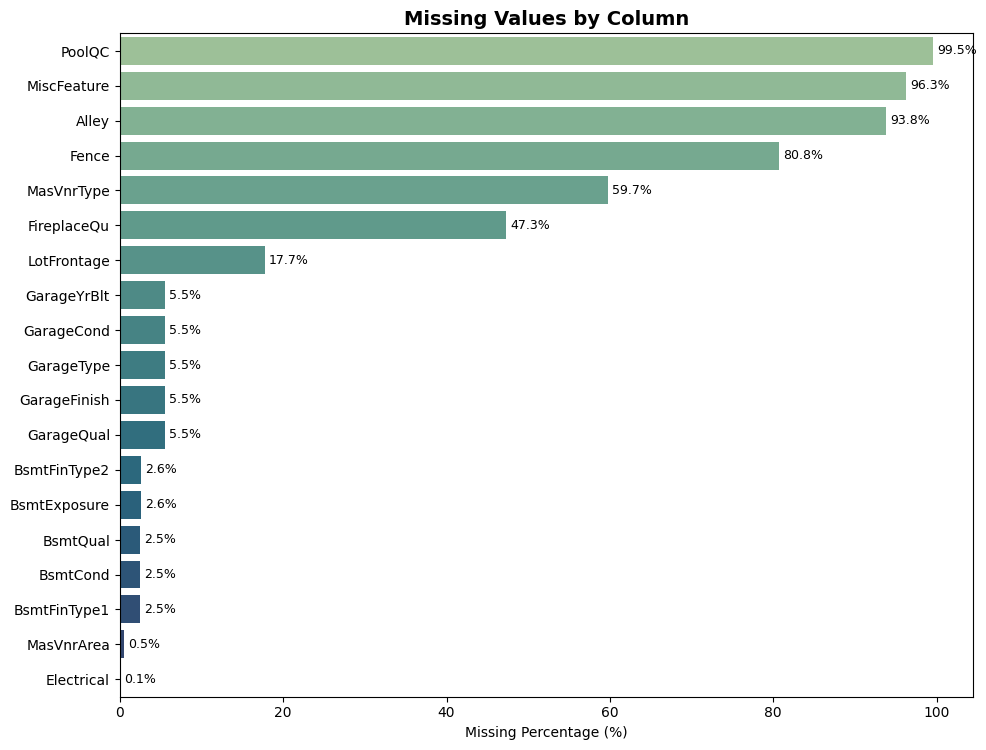

In [296]:
# Calculate missing percentages and filter out 0% columns
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]  # Exclude columns with 0% missing

# Adjust figure height dynamically based on number of columns
fig_height = max(6, len(missing_pct) * 0.4)  # Scale height with number of bars
plt.figure(figsize=(10, fig_height))

# Create the bar plot
ax = sns.barplot(
    x=missing_pct.values, 
    y=missing_pct.index, 
    hue=missing_pct.index, 
    palette="crest", 
    legend=False
)

# Add percentage labels on bars (optional but useful)
for i, v in enumerate(missing_pct.values):
    ax.text(v + 0.5, i, f'{v:.1f}%', va='center', fontsize=9)

plt.title("Missing Values by Column", fontsize=14, fontweight='bold')
plt.xlabel("Missing Percentage (%)")
plt.ylabel("")

# Prevent label overlapping
plt.tight_layout()

plt.show()

In [297]:
df['MiscFeature'].value_counts()

MiscFeature
Shed    49
Gar2     2
Othr     2
TenC     1
Name: count, dtype: int64

In [298]:
df.nunique().sort_values(ascending=True)

CentralAir         2
Utilities          2
Street             2
Alley              2
BsmtHalfBath       3
                ... 
1stFlrSF         753
BsmtUnfSF        780
GrLivArea        861
LotArea         1073
Id              1460
Length: 81, dtype: int64

In [299]:
#descriptive statistics summary
df['SalePrice'].describe()

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

<Axes: xlabel='SalePrice', ylabel='Density'>

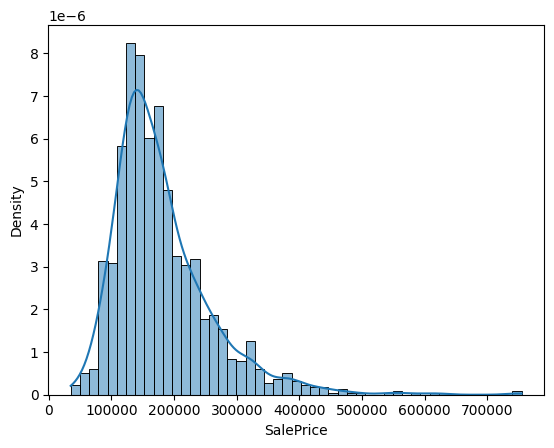

In [300]:
#histogram
sns.histplot(df["SalePrice"], kde=True, stat="density")

<Axes: xlabel='SalePrice', ylabel='Density'>

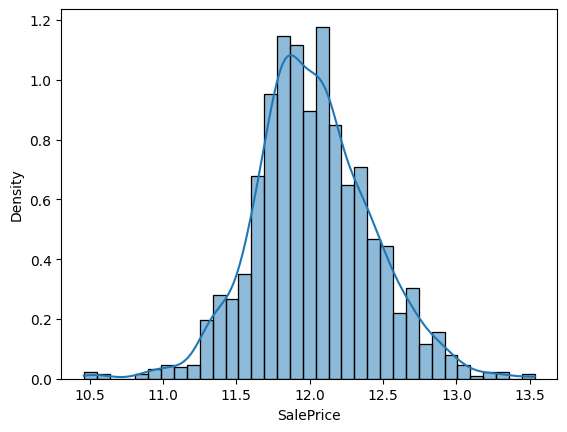

In [301]:
sns.histplot(np.log(df["SalePrice"]), kde=True, stat="density")


SalePrice vs feature dependecy

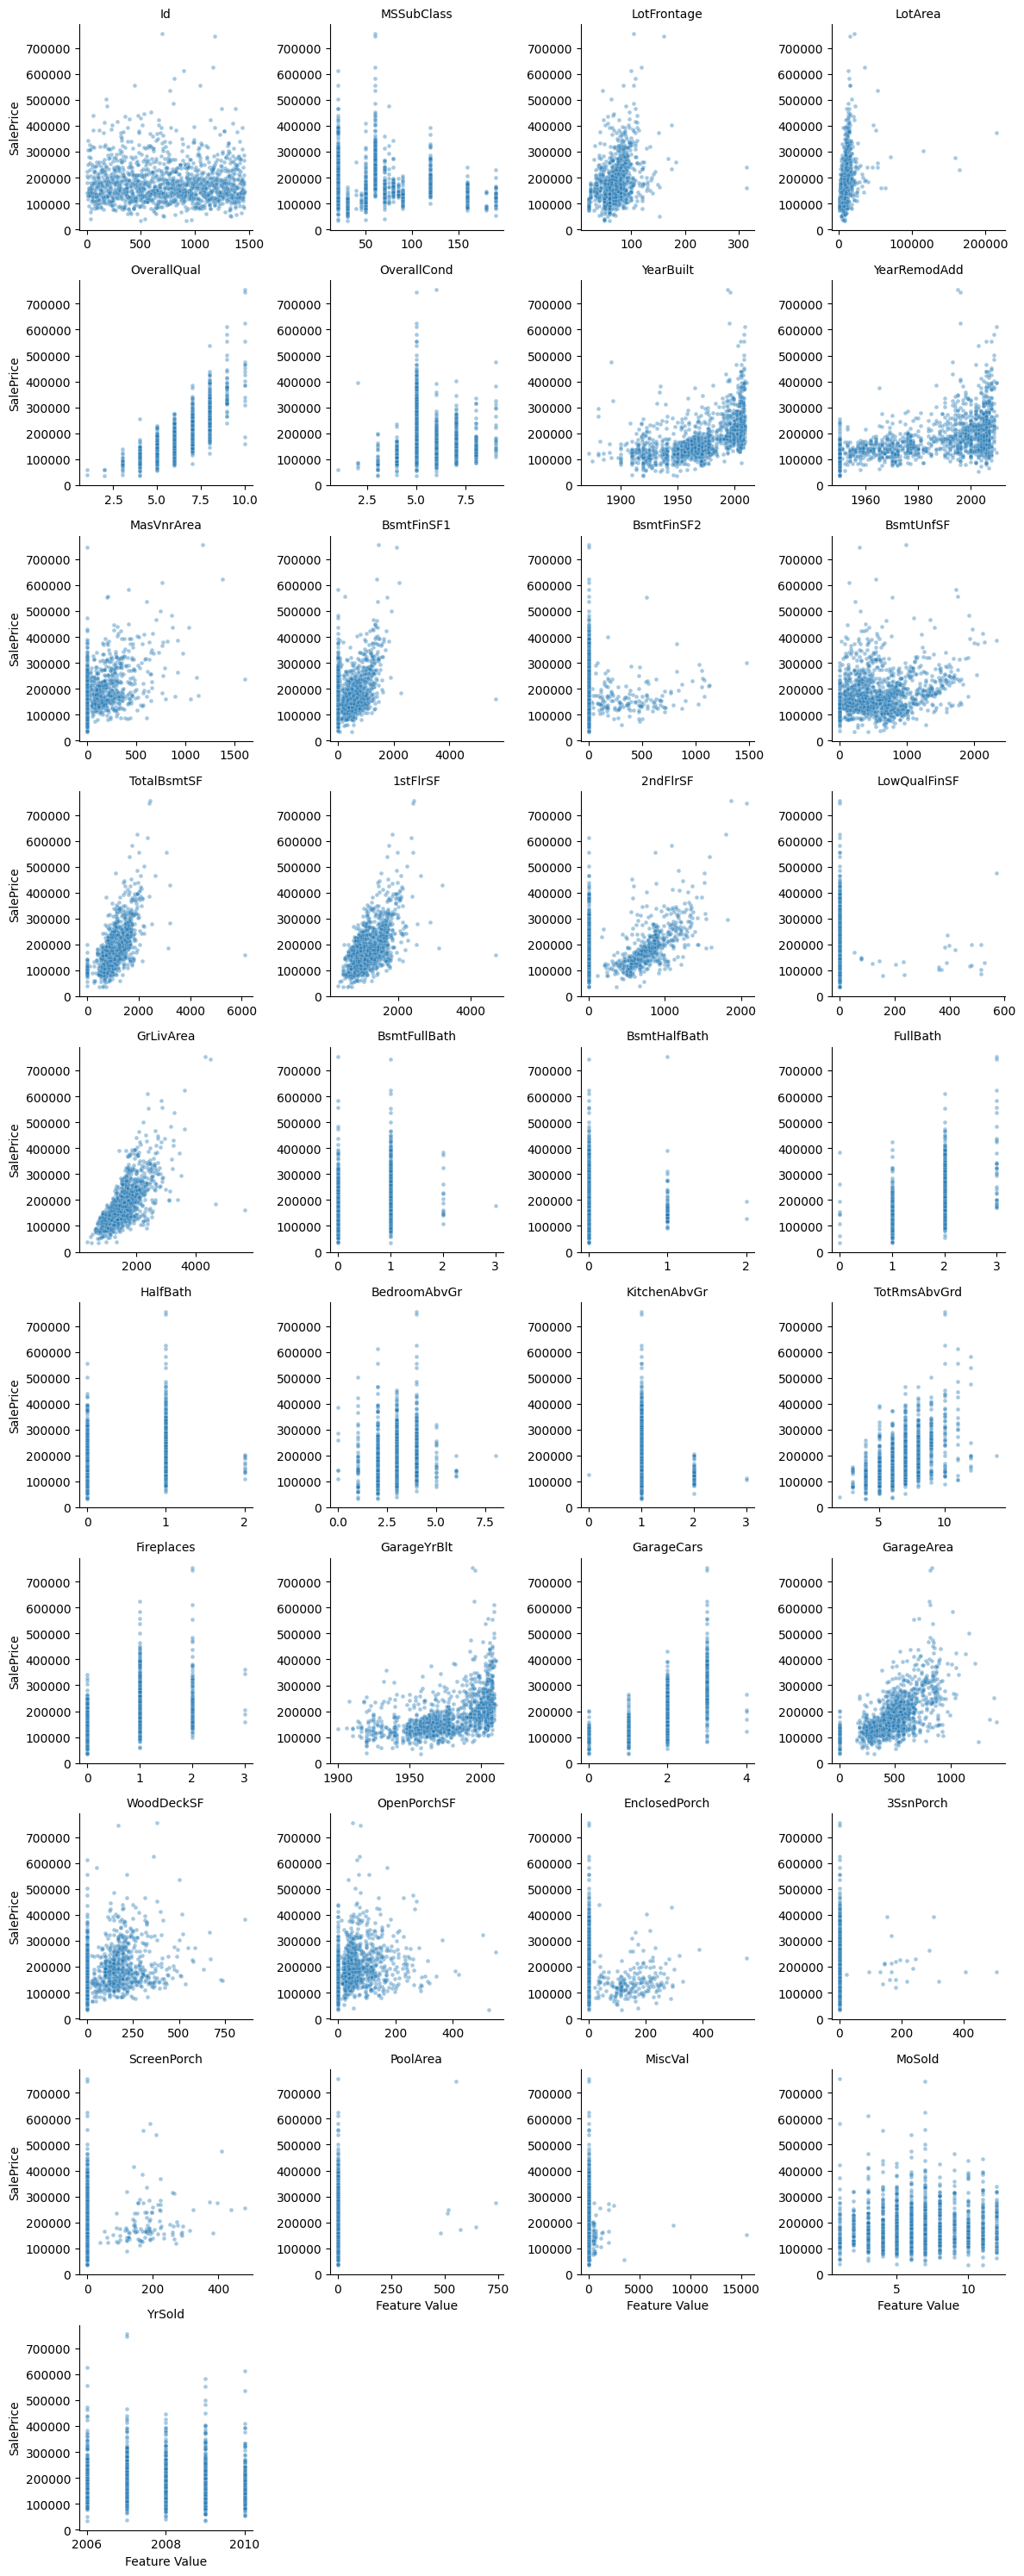

In [302]:
numeric_feature_columns = [column for column in df.select_dtypes(include='number').columns if column != 'SalePrice']

saleprice_scatter_data = (
    df[numeric_feature_columns + ['SalePrice']]
    .melt(id_vars='SalePrice', var_name='feature', value_name='feature_value')
)

saleprice_plot = sns.FacetGrid(
    saleprice_scatter_data,
    col='feature',
    col_wrap=4,
    sharex=False,
    sharey=False,
    height=3,
)
saleprice_plot.map_dataframe(sns.scatterplot, x='feature_value', y='SalePrice', alpha=0.4, s=12)
saleprice_plot.set_axis_labels('Feature Value', 'SalePrice')
saleprice_plot.set_titles('{col_name}')
plt.show()

Log(SalePrice) vs feature dependecy

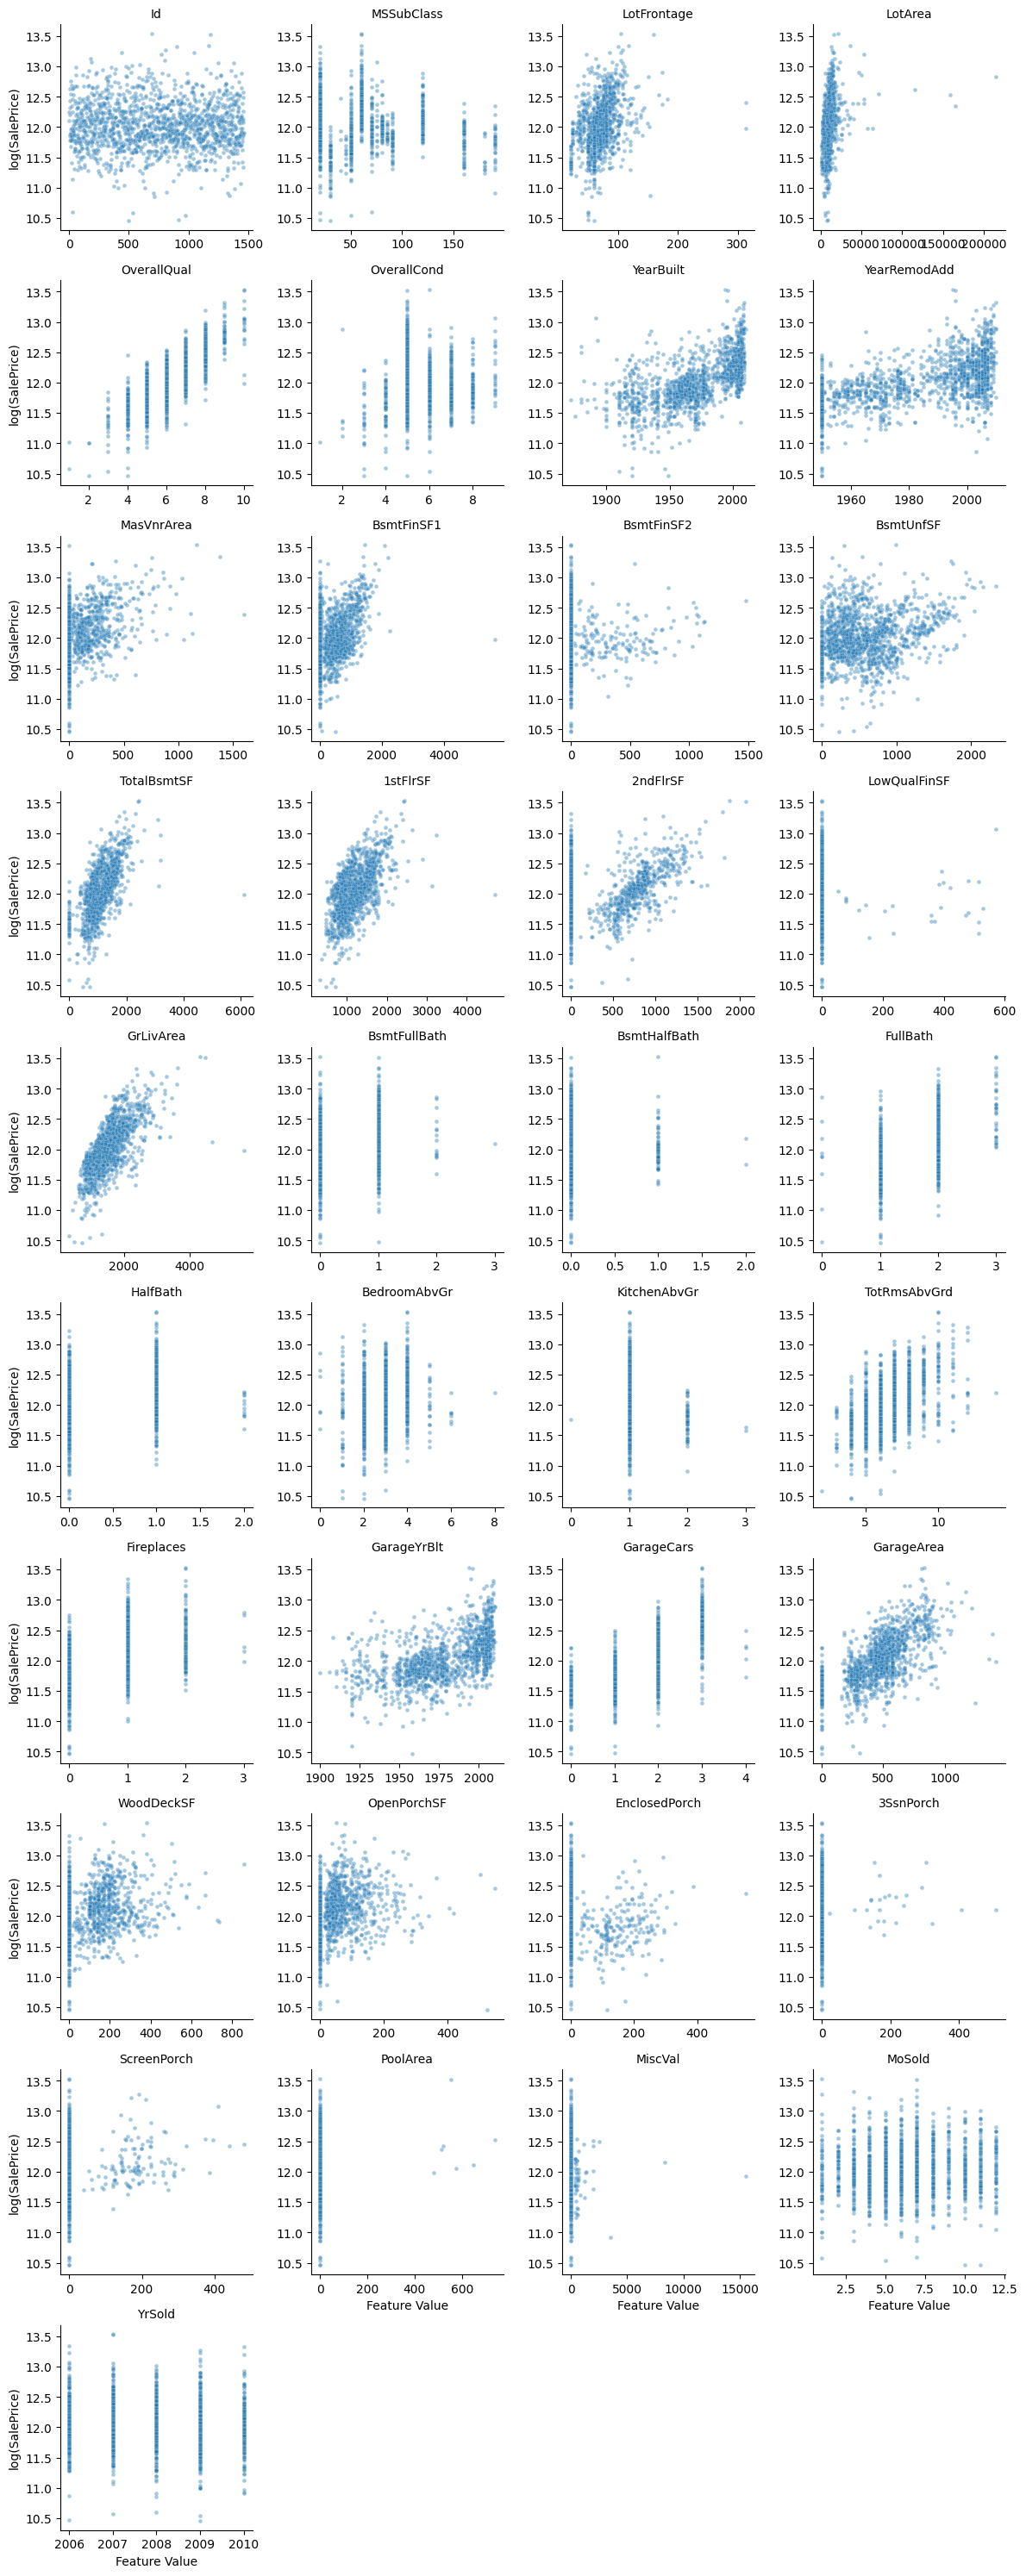

In [303]:
log_saleprice_scatter_data = (
    df[numeric_feature_columns + ['SalePrice']]
    .assign(LogSalePrice=np.log(df['SalePrice']))
    .drop(columns=['SalePrice'])
    .melt(id_vars='LogSalePrice', var_name='feature', value_name='feature_value')
)

log_saleprice_plot = sns.FacetGrid(
    log_saleprice_scatter_data,
    col='feature',
    col_wrap=4,
    sharex=False,
    sharey=False,
    height=3,
)
log_saleprice_plot.map_dataframe(sns.scatterplot, x='feature_value', y='LogSalePrice', alpha=0.4, s=12)
log_saleprice_plot.set_axis_labels('Feature Value', 'log(SalePrice)')
log_saleprice_plot.set_titles('{col_name}')
plt.show()

Feature categorization and ordinal mappings

In [304]:
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    mean_squared_error,
    r2_score,
)
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline

RANDOM_STATE = 42
N_SPLITS = 5
STRATIFY_BINS = 10
TARGET = 'SalePrice'
EXCLUDED_FEATURE_COLUMNS = {'Id'}

MISSING_CATEGORY_LABELS = {
    'Alley': 'NoAlleyAccess',
    'BsmtQual': 'NoBasement',
    'BsmtCond': 'NoBasement',
    'BsmtExposure': 'NoBasement',
    'BsmtFinType1': 'NoBasement',
    'BsmtFinType2': 'NoBasement',
    'FireplaceQu': 'NoFireplace',
    'GarageType': 'NoGarage',
    'GarageFinish': 'NoGarage',
    'GarageQual': 'NoGarage',
    'GarageCond': 'NoGarage',
    'PoolQC': 'NoPool',
    'Fence': 'NoFence',
    'MiscFeature': 'None',
}

ORDINAL_MAPPINGS = {
    'LotShape': {'Reg': 4, 'IR1': 3, 'IR2': 2, 'IR3': 1},
    'Utilities': {'AllPub': 4, 'NoSewr': 3, 'NoSeWa': 2, 'ELO': 1},
    'LandSlope': {'Gtl': 3, 'Mod': 2, 'Sev': 1},
    'ExterQual': {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1},
    'ExterCond': {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1},
    'BsmtQual': {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'NoBasement': 0},
    'BsmtCond': {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'NoBasement': 0},
    'BsmtExposure': {'Gd': 4, 'Av': 3, 'Mn': 2, 'No': 1, 'NoBasement': 0},
    'BsmtFinType1': {'GLQ': 6, 'ALQ': 5, 'BLQ': 4, 'Rec': 3, 'LwQ': 2, 'Unf': 1, 'NoBasement': 0},
    'BsmtFinType2': {'GLQ': 6, 'ALQ': 5, 'BLQ': 4, 'Rec': 3, 'LwQ': 2, 'Unf': 1, 'NoBasement': 0},
    'HeatingQC': {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1},
    'CentralAir': {'Y': 1, 'N': 0},
    'KitchenQual': {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1},
    'Functional': {'Typ': 7, 'Min1': 6, 'Min2': 5, 'Mod': 4, 'Maj1': 3, 'Maj2': 2, 'Sev': 1, 'Sal': 0},
    'FireplaceQu': {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'NoFireplace': 0},
    'GarageFinish': {'Fin': 3, 'RFn': 2, 'Unf': 1, 'NoGarage': 0},
    'GarageQual': {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'NoGarage': 0},
    'GarageCond': {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'NoGarage': 0},
    'PavedDrive': {'Y': 2, 'P': 1, 'N': 0},
    'PoolQC': {'Ex': 4, 'Gd': 3, 'TA': 2, 'Fa': 1, 'NoPool': 0},
    'Fence': {'GdPrv': 4, 'MnPrv': 3, 'GdWo': 2, 'MnWw': 1, 'NoFence': 0},
}


In [305]:
def prepare_common_data(df_input):
    """Apply the shared cleaning used by all model dataset versions."""
    df_prepared = df_input.copy()

    for column, fill_value in MISSING_CATEGORY_LABELS.items():
        if column in df_prepared.columns:
            df_prepared[column] = df_prepared[column].fillna(fill_value)

    for column, mapping in ORDINAL_MAPPINGS.items():
        if column in df_prepared.columns:
            df_prepared[column] = df_prepared[column].map(mapping)

    return df_prepared


def split_X_y(df_input, target=TARGET):
    drop_columns = [target, *EXCLUDED_FEATURE_COLUMNS]
    X = df_input.drop(columns=drop_columns, errors='ignore').copy()
    y = df_input[target].copy()
    return X, y


def log_target(y):
    y_series = y.copy() if isinstance(y, pd.Series) else pd.Series(y)
    y_series = y_series.astype(float)
    target_name = y_series.name or 'target'
    return pd.Series(np.log(y_series), index=y_series.index, name=f'log_{target_name}')


def to_log_saleprice(y):
    return np.log(np.asarray(y, dtype=float))


def from_log_saleprice(y_log):
    return np.exp(np.asarray(y_log, dtype=float))


def numeric_columns(df_input):
    return df_input.select_dtypes(include='number').columns.tolist()


def categorical_columns(df_input):
    return df_input.select_dtypes(include=['object', 'string', 'category']).columns.tolist()


def prepare_onehot_features(X_data):
    X_encoded = X_data.copy()
    onehot_categorical_columns = categorical_columns(X_encoded)

    for column in onehot_categorical_columns:
        X_encoded[column] = X_encoded[column].fillna('Missing').astype(str)

    if onehot_categorical_columns:
        X_encoded = pd.get_dummies(
            X_encoded,
            columns=onehot_categorical_columns,
            dtype=float,
        )

    return X_encoded


def get_ordinal_columns(X_data):
    return [column for column in ORDINAL_MAPPINGS if column in X_data.columns]


def get_scale_columns(X_data):
    return [
        column for column in X_data.columns
        if column not in get_ordinal_columns(X_data)
    ]


def build_numeric_preprocessor(dataset_data):
    return ColumnTransformer(
        transformers=[
            (
                'scaled_num',
                Pipeline([
                    ('imputer', SimpleImputer(strategy='median')),
                    ('scaler', StandardScaler()),
                ]),
                dataset_data.get('scale_columns', []),
            ),
            (
                'ordinal_passthrough',
                Pipeline([
                    ('imputer', SimpleImputer(strategy='most_frequent')),
                ]),
                dataset_data.get('ordinal_columns', []),
            ),
            (
                'non_scaled_passthrough',
                Pipeline([
                    ('imputer', SimpleImputer(strategy='most_frequent')),
                ]),
                dataset_data.get('non_scaled_columns', []),
            ),
        ],
        remainder='drop',
    )


def make_saleprice_strata(y, n_bins=STRATIFY_BINS):
    return pd.qcut(
        y,
        q=min(n_bins, y.nunique()),
        labels=False,
        duplicates='drop'
    )


def split_train_validation(X, y, validation_size=0.2):
    strata = make_saleprice_strata(y)
    X_train, X_val, y_train, y_val = train_test_split(
        X,
        y,
        test_size=validation_size,
        random_state=RANDOM_STATE,
        stratify=strata,
    )
    return X_train, X_val, y_train, y_val


def iter_stratified_folds(X, y, n_splits=N_SPLITS):
    strata = make_saleprice_strata(y)
    splitter = StratifiedKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=RANDOM_STATE
    )

    for fold, (train_idx, val_idx) in enumerate(splitter.split(X, strata), start=1):
        yield fold, X.iloc[train_idx], X.iloc[val_idx], y.iloc[train_idx], y.iloc[val_idx]


def log_saleprice_metrics(y_true_saleprice, y_pred_log_saleprice):
    y_true_saleprice = np.asarray(y_true_saleprice, dtype=float)
    y_true_log_saleprice = to_log_saleprice(y_true_saleprice)
    y_pred_log_saleprice = np.asarray(y_pred_log_saleprice, dtype=float)
    y_pred_saleprice = from_log_saleprice(y_pred_log_saleprice)
    abs_errors = np.abs(y_true_saleprice - y_pred_saleprice)

    return {
        'rmse_log_saleprice': np.sqrt(mean_squared_error(y_true_log_saleprice, y_pred_log_saleprice)),
        'rmse_saleprice': np.sqrt(mean_squared_error(y_true_saleprice, y_pred_saleprice)),
        'mae_saleprice': mean_absolute_error(y_true_saleprice, y_pred_saleprice),
        'r2_saleprice': r2_score(y_true_saleprice, y_pred_saleprice),
        'avg_pct_error': mean_absolute_percentage_error(y_true_saleprice, y_pred_saleprice) * 100,
        'max_abs_error_saleprice': abs_errors.max(),
        'min_abs_error_saleprice': abs_errors.min(),
    }


def prefix_metrics(metrics, prefix):
    return {f'{prefix}_{key}': value for key, value in metrics.items()}


def aggregate_cv_metrics(fold_metrics):
    fold_metrics_df = pd.DataFrame(fold_metrics)
    return {
        'cv_rmse_log_saleprice': fold_metrics_df['rmse_log_saleprice'].mean(),
        'cv_rmse_saleprice': fold_metrics_df['rmse_saleprice'].mean(),
        'cv_mae_saleprice': fold_metrics_df['mae_saleprice'].mean(),
        'cv_r2_saleprice': fold_metrics_df['r2_saleprice'].mean(),
        'cv_avg_pct_error': fold_metrics_df['avg_pct_error'].mean(),
        'cv_max_abs_error_saleprice': fold_metrics_df['max_abs_error_saleprice'].max(),
        'cv_min_abs_error_saleprice': fold_metrics_df['min_abs_error_saleprice'].min(),
    }


def summarize_model_results(result_rows, sort_columns=('val_rmse_log_saleprice',)):
    return pd.DataFrame(result_rows).sort_values(list(sort_columns)).reset_index(drop=True)


In [306]:
def make_linear_price_comparison_dataset(df_input):
    df_work = df_input.copy()
    df_work['PricePerSqFt'] = df_work[TARGET] / df_work['GrLivArea']
    df_work = df_work[np.isfinite(df_work['PricePerSqFt'])].copy()

    cutoff = df_work['PricePerSqFt'].quantile(0.99)
    df_work = df_work[df_work['PricePerSqFt'] <= cutoff].copy()

    X = (
        df_work
        .select_dtypes(include='number')
        .drop(columns=[TARGET, 'PricePerSqFt', *EXCLUDED_FEATURE_COLUMNS], errors='ignore')
        .copy()
    )
    y = df_work[TARGET].copy()
    recipe_ordinal_columns = get_ordinal_columns(X)
    scale_columns = get_scale_columns(X)
    non_scaled_columns = []

    return {
        'X': X,
        'y': y,
        'y_log': log_target(y),
        'y_log_ppsqft': log_target(df_work['PricePerSqFt'].rename('PricePerSqFt')),
        'target': 'LogSalePrice and LogPricePerSqFt',
        'cat_features': [],
        'ordinal_columns': recipe_ordinal_columns,
        'scale_columns': scale_columns,
        'non_scaled_columns': non_scaled_columns,
        'requires_scaling': True,
        'model_family': 'linear_distance_based',
        'description': (
            'Numeric dataset trimmed at the 99th percentile of PricePerSqFt. '
            'Designed for linear, KNN, and neural-network style price comparison experiments.'
        ),
        'metadata': {
            'price_per_sqft_cutoff': cutoff,
            'price_per_sqft': df_work['PricePerSqFt'].copy(),
        },
    }


def make_processed_full_numeric_dataset(df_input):
    X, y = split_X_y(df_input)
    X = X.select_dtypes(include='number').copy()
    ordinal_columns = get_ordinal_columns(X)
    scale_columns = get_scale_columns(X)
    non_scaled_columns = []
    return {
        'X': X,
        'y': y,
        'y_log': log_target(y),
        'target': 'LogSalePrice',
        'cat_features': [],
        'ordinal_columns': ordinal_columns,
        'scale_columns': scale_columns,
        'non_scaled_columns': non_scaled_columns,
        'requires_scaling': False,
        'model_family': 'numeric_models',
        'description': (
            'All numeric columns after common preparation. '
            'Remaining non-numeric categorical columns are excluded.'
        ),
    }


def make_processed_full_onehot_dataset(df_input):
    X, y = split_X_y(df_input)
    X = prepare_onehot_features(X)
    ordinal_columns = get_ordinal_columns(X)
    scale_columns = get_scale_columns(X)
    non_scaled_columns = []
    return {
        'X': X,
        'y': y,
        'y_log': log_target(y),
        'target': 'LogSalePrice',
        'cat_features': [],
        'ordinal_columns': ordinal_columns,
        'scale_columns': scale_columns,
        'non_scaled_columns': non_scaled_columns,
        'requires_scaling': False,
        'model_family': 'numeric_models',
        'encoding': 'onehot',
        'description': (
            'All prepared features with remaining categorical columns one-hot encoded. '
            'Designed for sklearn tree-based models that should use the full feature set.'
        ),
    }


def make_knn_dataset(df_input):
    data = make_processed_full_numeric_dataset(df_input)
    return {
        **data,
        'requires_scaling': True,
        'model_family': 'distance_based',
        'description': 'Numeric prepared features for KNN. Scaling is recommended.',
    }


def make_nn_dataset(df_input):
    data = make_processed_full_numeric_dataset(df_input)
    return {
        **data,
        'requires_scaling': True,
        'model_family': 'neural_network',
        'description': 'Numeric prepared features for neural networks. Scaling is recommended.',
    }


def make_catboost_dataset(df_input):
    X, y = split_X_y(df_input)
    cat_features = categorical_columns(X)

    for col in cat_features:
        X[col] = X[col].fillna('Missing').astype(str)

    return {
        'X': X,
        'y': y,
        'y_log': log_target(y),
        'target': 'LogSalePrice',
        'cat_features': cat_features,
        'requires_scaling': False,
        'model_family': 'boosting_categorical',
        'description': (
            'Mixed numeric/categorical prepared dataset for CatBoost. '
            'Ordinal features are numeric and remaining categoricals stay as strings.'
        ),
    }


DATASET_RECIPES = {
    'linear_price_comparison': make_linear_price_comparison_dataset,
    'processed_full_numeric': make_processed_full_numeric_dataset,
    'processed_full_onehot': make_processed_full_onehot_dataset,
    'knn_numeric': make_knn_dataset,
    'nn_numeric': make_nn_dataset,
    'catboost_processed_mixed': make_catboost_dataset,
}


def build_dataset_registry(df_input, recipes=DATASET_RECIPES):
    return {
        name: recipe(df_input)
        for name, recipe in recipes.items()
    }


def build_dataset_summary(dataset_registry):
    rows = []
    for name, data in dataset_registry.items():
        X_data = data['X']
        rows.append({
            'dataset_version': name,
            'rows': X_data.shape[0],
            'features': X_data.shape[1],
            'target': data.get('target'),
            'categorical_features': len(data.get('cat_features', [])),
            'requires_scaling': data.get('requires_scaling', False),
            'model_family': data.get('model_family', ''),
            'description': data.get('description', ''),
        })
    return pd.DataFrame(rows)


raw_train = df.copy()
raw_test = df_test.copy()
train_prepared = prepare_common_data(raw_train)
test_prepared = prepare_common_data(raw_test)

dataset_versions = build_dataset_registry(train_prepared)
dataset_summary = build_dataset_summary(dataset_versions)

ordinal_columns = [column for column in ORDINAL_MAPPINGS if column in train_prepared.columns]
preprocessing_summary = pd.DataFrame({
    'dtype_after_encoding': train_prepared[ordinal_columns].dtypes.astype(str),
    'train_missing_after_encoding': train_prepared[ordinal_columns].isna().sum(),
    'test_missing_after_encoding': test_prepared[ordinal_columns].isna().sum(),
})

dataset_summary


,dataset_version,rows,features,target,categorical_features,requires_scaling,model_family,description
0,linear_price_comparison,1445,57,LogSalePrice and LogPricePerSqFt,0,True,linear_distance_based,Numeric dataset trimmed at the 99th percentile...
1,processed_full_numeric,1460,57,LogSalePrice,0,False,numeric_models,All numeric columns after common preparation. ...
2,processed_full_onehot,1460,225,LogSalePrice,0,False,numeric_models,All prepared features with remaining categoric...
3,knn_numeric,1460,57,LogSalePrice,0,True,distance_based,Numeric prepared features for KNN. Scaling is ...
4,nn_numeric,1460,57,LogSalePrice,0,True,neural_network,Numeric prepared features for neural networks....
5,catboost_processed_mixed,1460,79,LogSalePrice,22,False,boosting_categorical,Mixed numeric/categorical prepared dataset for...


In [307]:
preprocessing_summary

,dtype_after_encoding,train_missing_after_encoding,test_missing_after_encoding
LotShape,int64,0,0
Utilities,int64,0,2
LandSlope,int64,0,0
ExterQual,int64,0,0
ExterCond,int64,0,0
BsmtQual,int64,0,0
BsmtCond,int64,0,0
BsmtExposure,int64,0,0
BsmtFinType1,int64,0,0
BsmtFinType2,int64,0,0


In [308]:
test_missing_columns = preprocessing_summary[
    preprocessing_summary['test_missing_after_encoding'] > 0
].index.tolist()

test_prepared[test_prepared[test_missing_columns].isna().any(axis=1)][test_missing_columns]

for column in test_missing_columns:
    valid_values = set(ORDINAL_MAPPINGS[column].keys())
    unexpected_values = sorted(
        raw_test.loc[
            raw_test[column].notna() & ~raw_test[column].isin(valid_values),
            column
        ].unique()
    )
    print(column, unexpected_values)


Utilities []
KitchenQual []
Functional []


In [309]:
# Correlation analysis for prepared numeric features
numeric_df = train_prepared.select_dtypes(include='number')

corr_matrix = numeric_df.corr()

print('Top correlations with SalePrice')
display(
    corr_matrix[TARGET]
    .sort_values(ascending=False)
    .to_frame('correlation_with_SalePrice')
)

print('Highly correlated feature pairs (|corr| > 0.80)')
upper = corr_matrix.abs().where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

high_corr_pairs = (
    upper.stack()
    .reset_index()
)

high_corr_pairs.columns = ['feature_1', 'feature_2', 'correlation']
high_corr_pairs = high_corr_pairs[high_corr_pairs['correlation'] > 0.80]
high_corr_pairs = high_corr_pairs.sort_values(by='correlation', ascending=False)

display(high_corr_pairs)


Top correlations with SalePrice


,correlation_with_SalePrice
SalePrice,1.000000
OverallQual,0.790982
GrLivArea,0.708624
ExterQual,0.682639
KitchenQual,0.659600
GarageCars,0.640409
GarageArea,0.623431
TotalBsmtSF,0.613581
1stFlrSF,0.605852
BsmtQual,0.585207


Highly correlated feature pairs (|corr| > 0.80)


,feature_1,feature_2,correlation
2641,GarageQual,GarageCond,0.959172
3121,PoolArea,PoolQC,0.899924
2521,GarageCars,GarageArea,0.882475
2281,Fireplaces,FireplaceQu,0.863241
571,YearBuilt,GarageYrBlt,0.825667
1688,GrLivArea,TotRmsAbvGrd,0.825489
1323,TotalBsmtSF,1stFlrSF,0.819530


Correlation matrix

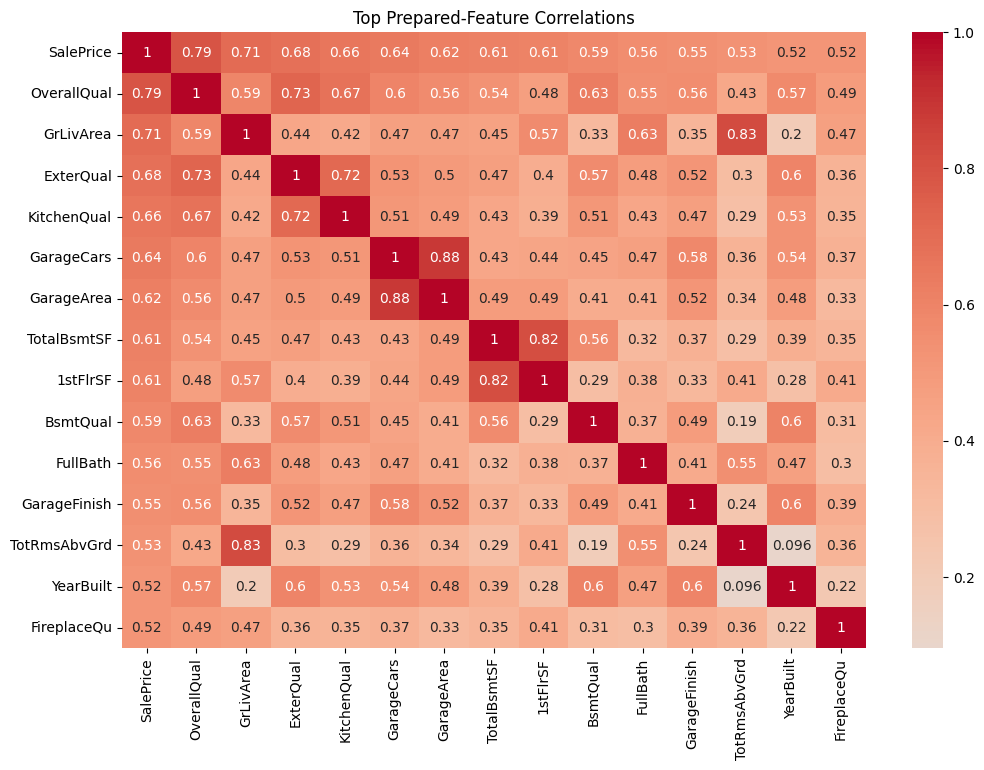

In [310]:
top_features = corr_matrix[TARGET].abs().sort_values(ascending=False).head(15).index

plt.figure(figsize=(12, 8))
sns.heatmap(train_prepared[top_features].corr(), annot=True, cmap='coolwarm', center=0)
plt.title('Top Prepared-Feature Correlations')
plt.show()


Dataset Recipes and Stratified K-Fold Setup

In [311]:
fold_summary = []

for dataset_name, data in dataset_versions.items():
    strata = make_saleprice_strata(data['y'])
    fold_summary.append({
        'dataset_version': dataset_name,
        'rows': len(data['y']),
        'features': data['X'].shape[1],
        'folds': N_SPLITS,
        'stratification': 'SalePrice quantile bins',
        'bins': strata.nunique(),
        'training_target': data['target'],
        'requires_scaling': data.get('requires_scaling', False),
        'model_family': data.get('model_family', ''),
    })

pd.DataFrame(fold_summary)


,dataset_version,rows,features,folds,stratification,bins,training_target,requires_scaling,model_family
0,linear_price_comparison,1445,57,5,SalePrice quantile bins,10,LogSalePrice and LogPricePerSqFt,True,linear_distance_based
1,processed_full_numeric,1460,57,5,SalePrice quantile bins,10,LogSalePrice,False,numeric_models
2,processed_full_onehot,1460,225,5,SalePrice quantile bins,10,LogSalePrice,False,numeric_models
3,knn_numeric,1460,57,5,SalePrice quantile bins,10,LogSalePrice,True,distance_based
4,nn_numeric,1460,57,5,SalePrice quantile bins,10,LogSalePrice,True,neural_network
5,catboost_processed_mixed,1460,79,5,SalePrice quantile bins,10,LogSalePrice,False,boosting_categorical


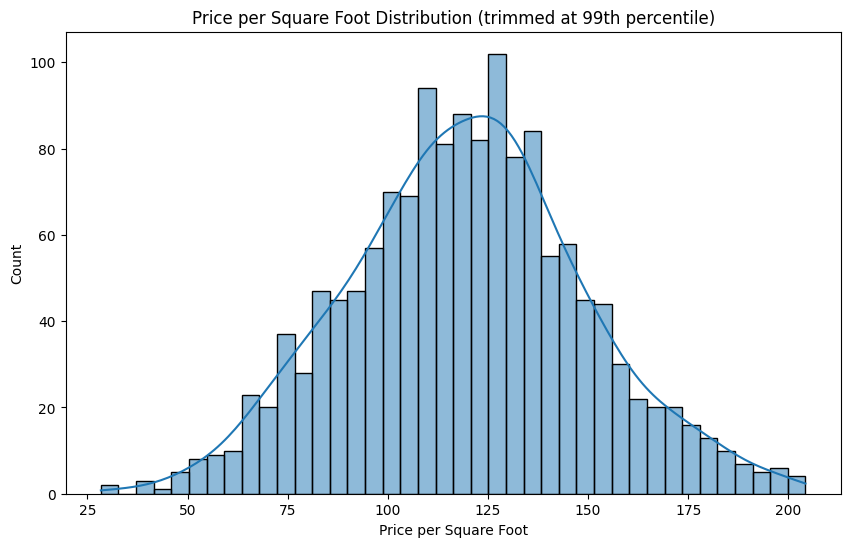

In [312]:
linear_plot_data = dataset_versions['linear_price_comparison']
price_per_sqft = linear_plot_data['metadata']['price_per_sqft']

plt.figure(figsize=(10, 6))
sns.histplot(price_per_sqft, kde=True, bins=40)
plt.title('Price per Square Foot Distribution (trimmed at 99th percentile)')
plt.xlabel('Price per Square Foot')
plt.ylabel('Count')
plt.show()


In [313]:
from sklearn.linear_model import ElasticNet, Lasso, LinearRegression, Ridge
#from sklearn.preprocessing import StandardScaler

linear_data = dataset_versions['linear_price_comparison']
feature_frame = linear_data['X']
y_sale = linear_data['y']
y_log_ppsqft = linear_data['y_log_ppsqft']
preprocessor = build_numeric_preprocessor(linear_data)

model_configs = {
    'LinearRegression': {
        'direct': LinearRegression(),
        'ppsqft': LinearRegression(),
    },
    'Lasso': {
        'direct': Lasso(alpha=0.001, max_iter=12000),
        'ppsqft': Lasso(alpha=0.432876, max_iter=12000),
    },
    'Ridge': {
        'direct': Ridge(alpha=1.0),
        'ppsqft': Ridge(alpha=0.432876),
    },
    'ElasticNet': {
        'direct': ElasticNet(alpha=2.477076, l1_ratio=0.7, max_iter=20000),
        'ppsqft': ElasticNet(alpha=0.432876, l1_ratio=1.0, max_iter=20000),
    },
}

X_train_outer, X_val_outer, y_train_outer, y_val_outer = split_train_validation(feature_frame, y_sale)

linear_result_rows = []

for model_name, estimators in model_configs.items():
    direct_fold_metrics = []
    for fold, X_train, X_val, y_sale_train, y_sale_val in iter_stratified_folds(X_train_outer, y_train_outer):
        saleprice_pipeline = Pipeline([
            ('preprocessor', clone(preprocessor)),
            ('model', clone(estimators['direct']))
        ])
        saleprice_pipeline.fit(X_train, to_log_saleprice(y_sale_train))
        saleprice_log_pred = saleprice_pipeline.predict(X_val)
        direct_fold_metrics.append(log_saleprice_metrics(y_sale_val, saleprice_log_pred))

    saleprice_pipeline = Pipeline([
        ('preprocessor', clone(preprocessor)),
        ('model', clone(estimators['direct']))
    ])
    saleprice_pipeline.fit(X_train_outer, to_log_saleprice(y_train_outer))
    saleprice_log_pred = saleprice_pipeline.predict(X_val_outer)

    linear_result_rows.append({
        'model': model_name,
        'target_strategy': 'Log SalePrice',
        **aggregate_cv_metrics(direct_fold_metrics),
        **prefix_metrics(log_saleprice_metrics(y_val_outer, saleprice_log_pred), 'val'),
    })

    ppsqft_fold_metrics = []
    for fold, X_train, X_val, y_sale_train, y_sale_val in iter_stratified_folds(X_train_outer, y_train_outer):
        ppsqft_pipeline = Pipeline([
            ('preprocessor', clone(preprocessor)),
            ('model', clone(estimators['ppsqft']))
        ])
        ppsqft_pipeline.fit(X_train, y_log_ppsqft.loc[X_train.index])
        ppsqft_log_pred = ppsqft_pipeline.predict(X_val)
        saleprice_log_from_ppsqft = ppsqft_log_pred + np.log(X_val['GrLivArea'].to_numpy())
        ppsqft_fold_metrics.append(log_saleprice_metrics(y_sale_val, saleprice_log_from_ppsqft))

    ppsqft_pipeline = Pipeline([
        ('preprocessor', clone(preprocessor)),
        ('model', clone(estimators['ppsqft']))
    ])
    ppsqft_pipeline.fit(X_train_outer, y_log_ppsqft.loc[X_train_outer.index])
    ppsqft_log_pred = ppsqft_pipeline.predict(X_val_outer)
    saleprice_log_from_ppsqft = ppsqft_log_pred + np.log(X_val_outer['GrLivArea'].to_numpy())

    linear_result_rows.append({
        'model': model_name,
        'target_strategy': 'Log PricePerSqFt -> Log SalePrice',
        **aggregate_cv_metrics(ppsqft_fold_metrics),
        **prefix_metrics(log_saleprice_metrics(y_val_outer, saleprice_log_from_ppsqft), 'val'),
    })

results_df = summarize_model_results(
    linear_result_rows,
    sort_columns=('val_rmse_log_saleprice',)
)
results_df

,model,target_strategy,cv_rmse_log_saleprice,cv_rmse_saleprice,cv_mae_saleprice,cv_r2_saleprice,cv_avg_pct_error,cv_max_abs_error_saleprice,cv_min_abs_error_saleprice,val_rmse_log_saleprice,val_rmse_saleprice,val_mae_saleprice,val_r2_saleprice,val_avg_pct_error,val_max_abs_error_saleprice,val_min_abs_error_saleprice
0,Ridge,Log PricePerSqFt -> Log SalePrice,0.153271,37619.945864,19198.507306,0.716048,11.036614,7.610991e+05,13.178437,0.138562,28731.406071,17743.189147,0.859494,10.232475,216604.943676,0.816626
1,LinearRegression,Log PricePerSqFt -> Log SalePrice,0.153565,37701.931815,19237.895521,0.714933,11.053979,7.620286e+05,5.116581,0.138587,28735.184819,17748.920419,0.859457,10.236290,216742.803839,11.826698
2,Lasso,Log SalePrice,0.152459,45972.779412,18466.984005,0.395815,10.850302,1.558924e+06,10.311765,0.139117,25296.809165,17253.063346,0.891079,10.354262,133317.071020,49.134613
3,Ridge,Log SalePrice,0.155606,47139.162709,18862.974458,0.381148,11.072947,1.558724e+06,6.483699,0.139702,25641.046842,17431.079751,0.888094,10.412594,130425.554052,3.797116
4,LinearRegression,Log SalePrice,0.156862,47630.325405,18984.470353,0.378051,11.127633,1.553818e+06,29.876425,0.139729,25636.552396,17434.609019,0.888133,10.415451,130380.067593,2.849782
5,Lasso,Log PricePerSqFt -> Log SalePrice,0.267085,51994.995635,36275.606329,0.500554,22.057121,4.955207e+05,12.603222,0.274035,53110.376436,38405.786365,0.519890,22.783813,224907.351711,360.593497
6,ElasticNet,Log PricePerSqFt -> Log SalePrice,0.267085,51994.995635,36275.606329,0.500554,22.057121,4.955207e+05,12.603222,0.274035,53110.376436,38405.786365,0.519890,22.783813,224907.351711,360.593497
7,ElasticNet,Log SalePrice,0.384020,75438.382149,52998.483898,-0.030287,31.358350,5.900236e+05,23.612146,0.408011,77799.696149,54486.020861,-0.030238,33.870970,459769.664752,230.335248


KNN model

In [314]:
from sklearn.neighbors import KNeighborsRegressor

knn_param_grid = {
    'n_neighbors': [3, 5, 7, 11, 15],
    'weights': ['uniform', 'distance'],
    'p': [1, 2],
}

X_train_outer, X_val_outer, y_train_outer, y_val_outer = split_train_validation(feature_frame, y_sale)

knn_result_rows = []

for n_neighbors in knn_param_grid['n_neighbors']:
    for weights in knn_param_grid['weights']:
        for p in knn_param_grid['p']:
            direct_fold_metrics = []
            for fold, X_train, X_val, y_sale_train, y_sale_val in iter_stratified_folds(X_train_outer, y_train_outer):
                direct_pipeline = Pipeline([
                    ('preprocessor', clone(preprocessor)),
                    ('model', KNeighborsRegressor(
                        n_neighbors=n_neighbors,
                        weights=weights,
                        p=p,
                        n_jobs=-1
                    ))
                ])
                direct_pipeline.fit(X_train, to_log_saleprice(y_sale_train))
                direct_log_pred = direct_pipeline.predict(X_val)
                direct_fold_metrics.append(log_saleprice_metrics(y_sale_val, direct_log_pred))

            direct_pipeline = Pipeline([
                ('preprocessor', clone(preprocessor)),
                ('model', KNeighborsRegressor(
                    n_neighbors=n_neighbors,
                    weights=weights,
                    p=p,
                    n_jobs=-1
                ))
            ])
            direct_pipeline.fit(X_train_outer, to_log_saleprice(y_train_outer))
            direct_log_pred = direct_pipeline.predict(X_val_outer)

            knn_result_rows.append({
                'target_strategy': 'Log SalePrice',
                'n_neighbors': n_neighbors,
                'weights': weights,
                'p': p,
                **aggregate_cv_metrics(direct_fold_metrics),
                **prefix_metrics(log_saleprice_metrics(y_val_outer, direct_log_pred), 'val'),
            })

            ppsqft_fold_metrics = []
            for fold, X_train, X_val, y_sale_train, y_sale_val in iter_stratified_folds(X_train_outer, y_train_outer):
                ppsqft_pipeline = Pipeline([
                    ('preprocessor', clone(preprocessor)),
                    ('model', KNeighborsRegressor(
                        n_neighbors=n_neighbors,
                        weights=weights,
                        p=p,
                        n_jobs=-1
                    ))
                ])
                ppsqft_pipeline.fit(X_train, y_log_ppsqft.loc[X_train.index])
                ppsqft_log_pred = ppsqft_pipeline.predict(X_val)
                saleprice_log_from_ppsqft = ppsqft_log_pred + np.log(X_val['GrLivArea'].to_numpy())
                ppsqft_fold_metrics.append(log_saleprice_metrics(y_sale_val, saleprice_log_from_ppsqft))

            ppsqft_pipeline = Pipeline([
                ('preprocessor', clone(preprocessor)),
                ('model', KNeighborsRegressor(
                    n_neighbors=n_neighbors,
                    weights=weights,
                    p=p,
                    n_jobs=-1
                ))
            ])
            ppsqft_pipeline.fit(X_train_outer, y_log_ppsqft.loc[X_train_outer.index])
            ppsqft_log_pred = ppsqft_pipeline.predict(X_val_outer)
            saleprice_log_from_ppsqft = ppsqft_log_pred + np.log(X_val_outer['GrLivArea'].to_numpy())

            knn_result_rows.append({
                'target_strategy': 'Log PricePerSqFt -> Log SalePrice',
                'n_neighbors': n_neighbors,
                'weights': weights,
                'p': p,
                **aggregate_cv_metrics(ppsqft_fold_metrics),
                **prefix_metrics(log_saleprice_metrics(y_val_outer, saleprice_log_from_ppsqft), 'val'),
            })

knn_results_df = summarize_model_results(
    knn_result_rows,
    sort_columns=('val_rmse_log_saleprice',)
)

knn_results_df

,target_strategy,n_neighbors,weights,p,cv_rmse_log_saleprice,cv_rmse_saleprice,cv_mae_saleprice,cv_r2_saleprice,cv_avg_pct_error,cv_max_abs_error_saleprice,cv_min_abs_error_saleprice,val_rmse_log_saleprice,val_rmse_saleprice,val_mae_saleprice,val_r2_saleprice,val_avg_pct_error,val_max_abs_error_saleprice,val_min_abs_error_saleprice
0,Log PricePerSqFt -> Log SalePrice,15,distance,1,0.172536,36168.377945,19995.341440,0.729572,12.712993,667409.813367,13.468357,0.159881,30236.859313,19811.397674,0.844384,11.956422,158987.539806,133.773334
1,Log PricePerSqFt -> Log SalePrice,15,uniform,1,0.175122,36677.867569,20344.949353,0.721599,12.963003,688987.762303,16.196959,0.161809,30592.370190,20248.665756,0.840703,12.221476,159545.887269,137.373081
2,Log PricePerSqFt -> Log SalePrice,11,distance,2,0.177035,38161.805176,21207.227400,0.706465,13.205788,659595.883495,32.618131,0.162715,31154.703776,20718.199402,0.834793,12.344351,182899.683340,99.285923
3,Log PricePerSqFt -> Log SalePrice,11,distance,1,0.171337,36442.279609,19933.376708,0.723906,12.623658,666373.796497,1.331707,0.163022,30614.441928,20031.865897,0.840473,12.196464,150267.352674,43.882381
4,Log PricePerSqFt -> Log SalePrice,15,distance,2,0.177460,38094.667082,21402.388890,0.709043,13.332108,655557.244732,17.862558,0.163126,31413.089958,20776.349025,0.832041,12.433486,174455.476760,97.365432
5,Log PricePerSqFt -> Log SalePrice,7,distance,1,0.170257,35850.129882,19913.024398,0.735179,12.605951,620828.394491,6.838257,0.163956,30093.988847,20227.473504,0.845851,12.481663,152088.935817,293.581141
6,Log PricePerSqFt -> Log SalePrice,11,uniform,2,0.178904,38560.566994,21464.415882,0.699605,13.382915,678483.029876,20.524841,0.164201,31318.574676,20977.112505,0.833050,12.528475,181180.091505,48.166146
7,Log PricePerSqFt -> Log SalePrice,7,distance,2,0.176231,37808.510542,21273.189323,0.719888,13.147498,595699.458860,2.171277,0.164599,32176.449915,21000.958371,0.823779,12.525086,205410.739153,25.704956
8,Log PricePerSqFt -> Log SalePrice,11,uniform,1,0.173695,37004.041670,20257.086694,0.714187,12.849188,695740.364659,40.946535,0.164924,30970.820391,20363.386406,0.836737,12.404175,151281.815786,131.122293
9,Log PricePerSqFt -> Log SalePrice,15,uniform,2,0.179320,38450.873940,21688.298317,0.703326,13.521402,668942.772186,115.797694,0.164983,31676.254858,21114.176149,0.829215,12.662799,172733.951672,19.913991


Decision tree

In [315]:
from sklearn.tree import DecisionTreeRegressor

processed_data = dataset_versions['processed_full_numeric']
X_processed = processed_data['X']
y_processed = processed_data['y']

tree_datasets = {
    'processed_full_numeric': processed_data,
    'processed_full_onehot': dataset_versions['processed_full_onehot'],
}

tree_param_grid = {
    'criterion': ['squared_error', 'friedman_mse', 'absolute_error', 'poisson'],
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5, 10],
}

tree_result_rows = []

for dataset_name, dataset_data in tree_datasets.items():
    X_data = dataset_data['X']
    y_data = dataset_data['y']
    X_train_outer, X_val_outer, y_train_outer, y_val_outer = split_train_validation(X_data, y_data)

    for criterion in tree_param_grid['criterion']:
        for max_depth in tree_param_grid['max_depth']:
            for min_samples_split in tree_param_grid['min_samples_split']:
                for min_samples_leaf in tree_param_grid['min_samples_leaf']:
                    fold_metrics = []
                    for fold, X_train_proc, X_val_proc, y_train_proc, y_val_proc in iter_stratified_folds(X_train_outer, y_train_outer):
                        tree_pipeline = Pipeline([
                            ('imputer', SimpleImputer(strategy='median')),
                            ('model', DecisionTreeRegressor(
                                criterion=criterion,
                                max_depth=max_depth,
                                min_samples_split=min_samples_split,
                                min_samples_leaf=min_samples_leaf,
                                random_state=RANDOM_STATE
                            ))
                        ])
                        tree_pipeline.fit(X_train_proc, to_log_saleprice(y_train_proc))
                        y_log_pred_proc = tree_pipeline.predict(X_val_proc)
                        fold_metrics.append(log_saleprice_metrics(y_val_proc, y_log_pred_proc))

                    tree_pipeline = Pipeline([
                        ('imputer', SimpleImputer(strategy='median')),
                        ('model', DecisionTreeRegressor(
                            criterion=criterion,
                            max_depth=max_depth,
                            min_samples_split=min_samples_split,
                            min_samples_leaf=min_samples_leaf,
                            random_state=RANDOM_STATE
                        ))
                    ])
                    tree_pipeline.fit(X_train_outer, to_log_saleprice(y_train_outer))
                    y_log_pred_proc = tree_pipeline.predict(X_val_outer)

                    tree_result_rows.append({
                        'dataset_version': dataset_name,
                        'criterion': criterion,
                        'max_depth': max_depth,
                        'min_samples_split': min_samples_split,
                        'min_samples_leaf': min_samples_leaf,
                        **aggregate_cv_metrics(fold_metrics),
                        **prefix_metrics(log_saleprice_metrics(y_val_outer, y_log_pred_proc), 'val'),
                    })

tree_results_df = summarize_model_results(
    tree_result_rows,
    sort_columns=('val_rmse_log_saleprice',)
)

tree_results_df

,dataset_version,criterion,max_depth,min_samples_split,min_samples_leaf,cv_rmse_log_saleprice,cv_rmse_saleprice,cv_mae_saleprice,cv_r2_saleprice,cv_avg_pct_error,cv_max_abs_error_saleprice,cv_min_abs_error_saleprice,val_rmse_log_saleprice,val_rmse_saleprice,val_mae_saleprice,val_r2_saleprice,val_avg_pct_error,val_max_abs_error_saleprice,val_min_abs_error_saleprice
0,processed_full_onehot,poisson,10.0,10,1,0.203715,40616.360672,26611.674218,0.735638,15.302336,312069.421606,1.146020e+01,0.160586,31499.617041,21876.839084,0.845227,12.353785,181136.852264,4.510251e+01
1,processed_full_onehot,poisson,10.0,20,2,0.197877,39418.019652,25605.839263,0.749895,14.793252,307938.902823,1.146020e+01,0.160963,32811.784861,22167.296493,0.832064,12.352143,215903.428640,1.127603e+01
2,processed_full_onehot,friedman_mse,10.0,10,1,0.207336,42388.185331,26932.951617,0.712322,15.488270,570250.000000,1.146020e+01,0.161223,31117.433953,22187.986060,0.848960,12.509150,174144.251277,8.805938e+01
3,processed_full_onehot,poisson,10.0,10,2,0.203615,42054.737596,26925.033477,0.716503,15.326215,452580.369589,4.644895e+00,0.161242,31460.137523,21915.967167,0.845615,12.390361,174144.251277,4.510251e+01
4,processed_full_onehot,squared_error,10.0,10,1,0.204060,40837.293672,26794.647243,0.732936,15.344216,312069.421606,1.146020e+01,0.161456,31158.672927,22187.986060,0.848560,12.513549,174144.251277,8.805938e+01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
635,processed_full_numeric,absolute_error,20.0,5,1,0.230528,43679.758378,28312.194284,0.693871,16.198064,361683.893532,0.000000e+00,0.229463,43442.187221,27883.344004,0.705621,15.629172,296657.000000,5.820766e-11
636,processed_full_numeric,absolute_error,10.0,2,1,0.228973,44470.396437,28004.581352,0.683464,16.135524,570250.000000,1.164153e-10,0.230060,41472.554765,28093.732898,0.731709,15.690683,195000.000000,2.910383e-11
637,processed_full_onehot,absolute_error,NaN,2,1,0.227247,44695.880749,28250.223059,0.681144,16.154891,370250.000000,2.182787e-11,0.233080,44321.498551,27103.866438,0.693583,15.561889,296657.000000,2.910383e-11
638,processed_full_numeric,absolute_error,NaN,2,1,0.232695,44487.476371,28424.751066,0.682105,16.395635,371831.000000,2.910383e-11,0.237518,42648.482079,27634.400685,0.716279,15.609150,296657.000000,2.910383e-11


In [316]:
tree_results_df.head(10)

,dataset_version,criterion,max_depth,min_samples_split,min_samples_leaf,cv_rmse_log_saleprice,cv_rmse_saleprice,cv_mae_saleprice,cv_r2_saleprice,cv_avg_pct_error,cv_max_abs_error_saleprice,cv_min_abs_error_saleprice,val_rmse_log_saleprice,val_rmse_saleprice,val_mae_saleprice,val_r2_saleprice,val_avg_pct_error,val_max_abs_error_saleprice,val_min_abs_error_saleprice
0,processed_full_onehot,poisson,10.0,10,1,0.203715,40616.360672,26611.674218,0.735638,15.302336,312069.421606,11.460201,0.160586,31499.617041,21876.839084,0.845227,12.353785,181136.852264,45.102512
1,processed_full_onehot,poisson,10.0,20,2,0.197877,39418.019652,25605.839263,0.749895,14.793252,307938.902823,11.460201,0.160963,32811.784861,22167.296493,0.832064,12.352143,215903.428640,11.276028
2,processed_full_onehot,friedman_mse,10.0,10,1,0.207336,42388.185331,26932.951617,0.712322,15.488270,570250.000000,11.460201,0.161223,31117.433953,22187.986060,0.848960,12.509150,174144.251277,88.059377
3,processed_full_onehot,poisson,10.0,10,2,0.203615,42054.737596,26925.033477,0.716503,15.326215,452580.369589,4.644895,0.161242,31460.137523,21915.967167,0.845615,12.390361,174144.251277,45.102512
4,processed_full_onehot,squared_error,10.0,10,1,0.204060,40837.293672,26794.647243,0.732936,15.344216,312069.421606,11.460201,0.161456,31158.672927,22187.986060,0.848560,12.513549,174144.251277,88.059377
5,processed_full_numeric,poisson,10.0,10,2,0.196467,39126.516246,25966.065551,0.752134,14.724864,307938.902823,4.644895,0.161828,30784.510662,21491.533856,0.852175,12.173058,174144.251277,130.353196
6,processed_full_numeric,poisson,15.0,10,2,0.198273,40427.937824,26150.544418,0.736082,14.881096,452580.369589,4.644895,0.161898,30698.190646,21667.633839,0.853003,12.296108,174144.251277,130.353196
7,processed_full_onehot,poisson,10.0,20,1,0.196982,38446.645083,25033.223087,0.762676,14.583743,288146.622168,11.460201,0.162073,32953.484165,22316.253813,0.830611,12.463313,215903.428640,11.276028
8,processed_full_numeric,poisson,20.0,10,2,0.198441,40484.058347,26226.060327,0.735379,14.906413,452580.369589,4.644895,0.162698,30789.678230,21887.777134,0.852125,12.452642,174144.251277,130.353196
9,processed_full_numeric,poisson,NaN,10,2,0.198441,40484.058347,26226.060327,0.735379,14.906413,452580.369589,4.644895,0.162698,30789.678230,21887.777134,0.852125,12.452642,174144.251277,130.353196


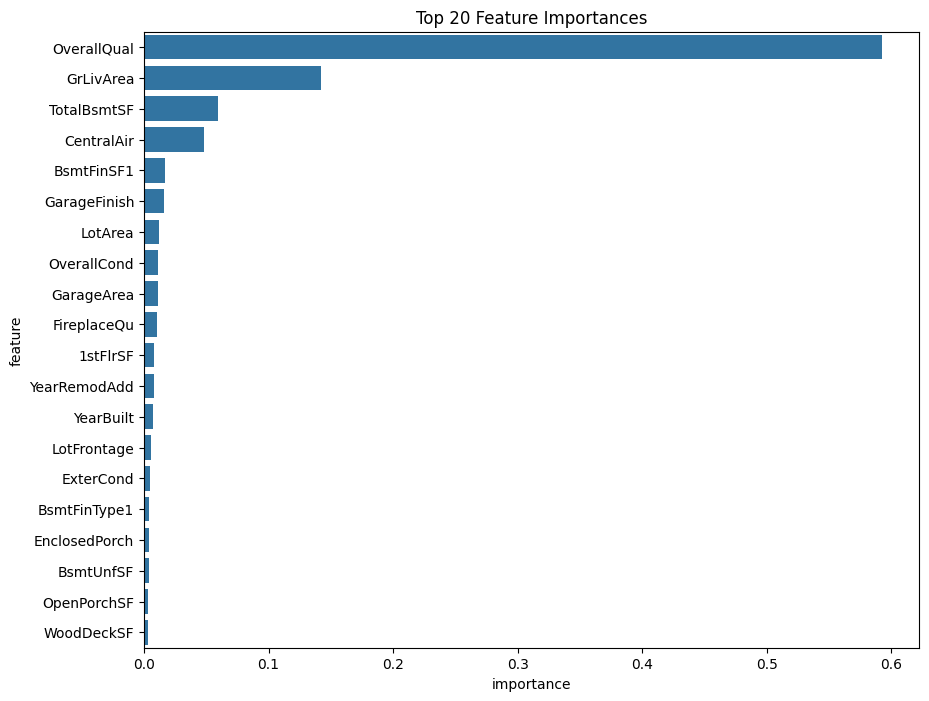

In [317]:
best_tree_params = tree_results_df.iloc[0]

best_max_depth = None if pd.isna(best_tree_params['max_depth']) else int(best_tree_params['max_depth'])

processed_tree = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model', DecisionTreeRegressor(
        criterion=best_tree_params['criterion'],
        max_depth=best_max_depth,
        min_samples_split=int(best_tree_params['min_samples_split']),
        min_samples_leaf=int(best_tree_params['min_samples_leaf']),
        random_state=RANDOM_STATE
    ))
])

processed_tree.fit(X_processed, to_log_saleprice(y_processed))
tree_model = processed_tree.named_steps['model']

feature_importances_df = pd.DataFrame({
    'feature': X_processed.columns,
    'importance': tree_model.feature_importances_
}).sort_values('importance', ascending=False)

feature_importances_df

top_n = 20
top_features = feature_importances_df.head(top_n)

plt.figure(figsize=(10, 8))
sns.barplot(data=top_features, x='importance', y='feature')
plt.title(f'Top {top_n} Feature Importances')
plt.show()


Feature importance is used to create a reduced dataset

In [318]:
#Keep only features with importance > 0.1
important_features = feature_importances_df.loc[
    feature_importances_df['importance'] > 0.1, 'feature'
].tolist()

X_processed_reduced = X_processed[important_features].copy()
dataset_versions['processed_reduced_numeric'] = {
    'X': X_processed_reduced,
    'y': y_processed,
    'y_log': pd.Series(to_log_saleprice(y_processed), index=y_processed.index),
    'target': 'LogSalePrice',
    'cat_features': [],
    'ordinal_columns': get_ordinal_columns(X_processed_reduced),
    'scale_columns': get_scale_columns(X_processed_reduced),
    'non_scaled_columns': [],
    'requires_scaling': False,
    'model_family': 'numeric_models',
    'description': 'Feature-importance subset from processed_full_numeric, keeping features with importance > 0.1.',
}
dataset_summary = build_dataset_summary(dataset_versions)

X_train_outer, X_val_outer, y_train_outer, y_val_outer = split_train_validation(X_processed_reduced, y_processed)

# Train a new Decision Tree on the reduced dataset
reduced_tree_fold_metrics = []

for fold, X_train_red, X_val_red, y_train_red, y_val_red in iter_stratified_folds(X_train_outer, y_train_outer):
    reduced_tree = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('model', DecisionTreeRegressor(
            max_depth=15,
            min_samples_split=2,
            min_samples_leaf=1,
            criterion='poisson',
            random_state=RANDOM_STATE
        ))
    ])

    reduced_tree.fit(X_train_red, to_log_saleprice(y_train_red))
    y_log_pred_red = reduced_tree.predict(X_val_red)
    reduced_tree_fold_metrics.append(log_saleprice_metrics(y_val_red, y_log_pred_red))

reduced_tree = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model', DecisionTreeRegressor(
        max_depth=15,
        min_samples_split=2,
        min_samples_leaf=1,
        criterion='poisson',
        random_state=RANDOM_STATE
    ))
])
reduced_tree.fit(X_train_outer, to_log_saleprice(y_train_outer))
y_log_pred_red = reduced_tree.predict(X_val_outer)

reduced_tree_results = summarize_model_results([
    {
        'n_features': len(important_features),
        'features_used': important_features,
        **aggregate_cv_metrics(reduced_tree_fold_metrics),
        **prefix_metrics(log_saleprice_metrics(y_val_outer, y_log_pred_red), 'val'),
    }
], sort_columns=('val_rmse_log_saleprice',))

reduced_tree_results

,n_features,features_used,cv_rmse_log_saleprice,cv_rmse_saleprice,cv_mae_saleprice,cv_r2_saleprice,cv_avg_pct_error,cv_max_abs_error_saleprice,cv_min_abs_error_saleprice,val_rmse_log_saleprice,val_rmse_saleprice,val_mae_saleprice,val_r2_saleprice,val_avg_pct_error,val_max_abs_error_saleprice,val_min_abs_error_saleprice
0,2,"[OverallQual, GrLivArea]",0.253109,48090.472336,32840.240565,0.630643,19.549651,570250.0,0.0,0.233396,44165.232481,30571.562419,0.69574,17.471319,266657.0,100.0


In [319]:
linear_reduced_fold_metrics = []

X_train_outer, X_val_outer, y_train_outer, y_val_outer = split_train_validation(X_processed_reduced, y_processed)

for fold, X_train_red, X_val_red, y_train_red, y_val_red in iter_stratified_folds(X_train_outer, y_train_outer):
    linear_reduced = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('model', LinearRegression())
    ])

    linear_reduced.fit(X_train_red, to_log_saleprice(y_train_red))
    y_log_pred_linear_red = linear_reduced.predict(X_val_red)
    linear_reduced_fold_metrics.append(log_saleprice_metrics(y_val_red, y_log_pred_linear_red))

linear_reduced = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model', LinearRegression())
])
linear_reduced.fit(X_train_outer, to_log_saleprice(y_train_outer))
y_log_pred_linear_red = linear_reduced.predict(X_val_outer)

linear_reduced_results = summarize_model_results([
    {
        'model': 'LinearRegression',
        'n_features': len(important_features),
        'features_used': important_features,
        **aggregate_cv_metrics(linear_reduced_fold_metrics),
        **prefix_metrics(log_saleprice_metrics(y_val_outer, y_log_pred_linear_red), 'val'),
    }
], sort_columns=('val_rmse_log_saleprice',))

linear_reduced_results

,model,n_features,features_used,cv_rmse_log_saleprice,cv_rmse_saleprice,cv_mae_saleprice,cv_r2_saleprice,cv_avg_pct_error,cv_max_abs_error_saleprice,cv_min_abs_error_saleprice,val_rmse_log_saleprice,val_rmse_saleprice,val_mae_saleprice,val_r2_saleprice,val_avg_pct_error,val_max_abs_error_saleprice,val_min_abs_error_saleprice
0,LinearRegression,2,"[OverallQual, GrLivArea]",0.207471,44519.927694,26526.655192,0.659902,15.862646,842547.946289,27.264287,0.191039,37457.677368,26071.615515,0.78114,15.446207,268024.75382,189.463009


Sklearn random forest

In [320]:
from sklearn.ensemble import RandomForestRegressor


rf_param_grid = {
    'n_estimators': [100, 300],
    'criterion': ['squared_error'],#'absolute_error'
    'max_depth': [10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5],
    'max_features': [1.0, 'sqrt'],
    'bootstrap': [True],
}


rf_datasets = {
    'processed_full_numeric': dataset_versions['processed_full_numeric'],
    'processed_full_onehot': dataset_versions['processed_full_onehot'],
    'processed_reduced_numeric': dataset_versions['processed_reduced_numeric'],
}

rf_result_rows = []

for dataset_name, dataset_data in rf_datasets.items():
    X_data = dataset_data['X']
    y_data = dataset_data['y']
    X_train_outer, X_val_outer, y_train_outer, y_val_outer = split_train_validation(X_data, y_data)

    for n_estimators in rf_param_grid['n_estimators']:
        for criterion in rf_param_grid['criterion']:
            for max_depth in rf_param_grid['max_depth']:
                for min_samples_split in rf_param_grid['min_samples_split']:
                    for min_samples_leaf in rf_param_grid['min_samples_leaf']:
                        for max_features in rf_param_grid['max_features']:
                            for bootstrap in rf_param_grid['bootstrap']:
                                fold_metrics = []
                                for fold, X_train_rf, X_val_rf, y_train_rf, y_val_rf in iter_stratified_folds(X_train_outer, y_train_outer):
                                    rf_pipeline = Pipeline([
                                        ('imputer', SimpleImputer(strategy='median')),
                                        ('model', RandomForestRegressor(
                                            n_estimators=n_estimators,
                                            criterion=criterion,
                                            max_depth=max_depth,
                                            min_samples_split=min_samples_split,
                                            min_samples_leaf=min_samples_leaf,
                                            max_features=max_features,
                                            bootstrap=bootstrap,
                                            random_state=RANDOM_STATE,
                                            n_jobs=-1
                                        ))
                                    ])
                                    rf_pipeline.fit(X_train_rf, to_log_saleprice(y_train_rf))
                                    y_log_pred_rf = rf_pipeline.predict(X_val_rf)
                                    fold_metrics.append(log_saleprice_metrics(y_val_rf, y_log_pred_rf))

                                rf_pipeline = Pipeline([
                                    ('imputer', SimpleImputer(strategy='median')),
                                    ('model', RandomForestRegressor(
                                        n_estimators=n_estimators,
                                        criterion=criterion,
                                        max_depth=max_depth,
                                        min_samples_split=min_samples_split,
                                        min_samples_leaf=min_samples_leaf,
                                        max_features=max_features,
                                        bootstrap=bootstrap,
                                        random_state=RANDOM_STATE,
                                        n_jobs=-1
                                    ))
                                ])
                                rf_pipeline.fit(X_train_outer, to_log_saleprice(y_train_outer))
                                y_log_pred_rf = rf_pipeline.predict(X_val_outer)

                                rf_result_rows.append({
                                    'dataset': dataset_name,
                                    'n_estimators': n_estimators,
                                    'criterion': criterion,
                                    'max_depth': max_depth,
                                    'min_samples_split': min_samples_split,
                                    'min_samples_leaf': min_samples_leaf,
                                    'max_features': max_features,
                                    'bootstrap': bootstrap,
                                    **aggregate_cv_metrics(fold_metrics),
                                    **prefix_metrics(log_saleprice_metrics(y_val_outer, y_log_pred_rf), 'val'),
                                })

rf_results_df = summarize_model_results(
    rf_result_rows,
    sort_columns=('val_rmse_log_saleprice',)
)

rf_results_df

,dataset,n_estimators,criterion,max_depth,min_samples_split,min_samples_leaf,max_features,bootstrap,cv_rmse_log_saleprice,cv_rmse_saleprice,...,cv_avg_pct_error,cv_max_abs_error_saleprice,cv_min_abs_error_saleprice,val_rmse_log_saleprice,val_rmse_saleprice,val_mae_saleprice,val_r2_saleprice,val_avg_pct_error,val_max_abs_error_saleprice,val_min_abs_error_saleprice
0,processed_full_numeric,100,squared_error,30,2,1,1.0,True,0.146574,30420.641307,...,10.362086,311339.215236,16.373894,0.124500,25004.492215,15634.465772,0.902474,8.897876,203917.944001,14.417534
1,processed_full_onehot,300,squared_error,30,2,2,1.0,True,0.145489,30826.054222,...,10.218353,329411.381392,1.684836,0.124937,25392.528941,15895.033168,0.899424,9.029074,193534.701878,60.268156
2,processed_full_onehot,300,squared_error,20,2,2,1.0,True,0.145505,30821.497426,...,10.220051,330371.326750,3.576713,0.124971,25447.460698,15900.374482,0.898988,9.027771,195535.077331,43.471133
3,processed_full_onehot,300,squared_error,30,5,2,1.0,True,0.145579,30896.993976,...,10.236596,329384.528332,31.149185,0.125072,25517.014879,15880.177061,0.898435,9.001794,195123.312129,54.030560
4,processed_full_onehot,300,squared_error,20,5,2,1.0,True,0.145582,30900.189969,...,10.235830,329854.297880,44.612518,0.125074,25514.358287,15881.180398,0.898456,9.003274,195364.093243,69.686442
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
319,processed_reduced_numeric,100,squared_error,30,2,1,sqrt,True,0.219749,41658.839074,...,17.089601,333998.377714,3.353375,0.208443,39769.696145,27554.354219,0.753289,16.095429,268597.469725,87.167063
320,processed_reduced_numeric,300,squared_error,20,2,1,1.0,True,0.220525,41866.488843,...,17.172506,337961.373587,15.177704,0.209510,39791.741703,27761.614379,0.753016,16.214378,263387.242629,315.030075
321,processed_reduced_numeric,300,squared_error,30,2,1,1.0,True,0.220561,41868.257913,...,17.175990,337961.373587,22.830046,0.209575,39810.334839,27768.072680,0.752785,16.217400,263361.099008,337.628137
322,processed_reduced_numeric,100,squared_error,20,2,1,1.0,True,0.221118,41999.655098,...,17.205064,333640.351274,64.431659,0.210084,40021.645598,27836.498276,0.750153,16.239349,263076.244218,0.187676


In [321]:
rf_results_df.head(20)


,dataset,n_estimators,criterion,max_depth,min_samples_split,min_samples_leaf,max_features,bootstrap,cv_rmse_log_saleprice,cv_rmse_saleprice,...,cv_avg_pct_error,cv_max_abs_error_saleprice,cv_min_abs_error_saleprice,val_rmse_log_saleprice,val_rmse_saleprice,val_mae_saleprice,val_r2_saleprice,val_avg_pct_error,val_max_abs_error_saleprice,val_min_abs_error_saleprice
0,processed_full_numeric,100,squared_error,30,2,1,1.0,True,0.146574,30420.641307,...,10.362086,311339.215236,16.373894,0.124500,25004.492215,15634.465772,0.902474,8.897876,203917.944001,14.417534
1,processed_full_onehot,300,squared_error,30,2,2,1.0,True,0.145489,30826.054222,...,10.218353,329411.381392,1.684836,0.124937,25392.528941,15895.033168,0.899424,9.029074,193534.701878,60.268156
2,processed_full_onehot,300,squared_error,20,2,2,1.0,True,0.145505,30821.497426,...,10.220051,330371.326750,3.576713,0.124971,25447.460698,15900.374482,0.898988,9.027771,195535.077331,43.471133
3,processed_full_onehot,300,squared_error,30,5,2,1.0,True,0.145579,30896.993976,...,10.236596,329384.528332,31.149185,0.125072,25517.014879,15880.177061,0.898435,9.001794,195123.312129,54.030560
4,processed_full_onehot,300,squared_error,20,5,2,1.0,True,0.145582,30900.189969,...,10.235830,329854.297880,44.612518,0.125074,25514.358287,15881.180398,0.898456,9.003274,195364.093243,69.686442
5,processed_full_numeric,300,squared_error,30,2,1,1.0,True,0.145958,30316.979978,...,10.304091,327791.561242,11.364331,0.125265,25508.656862,15641.518049,0.898502,8.872505,211458.763752,68.691459
6,processed_full_onehot,100,squared_error,30,2,2,1.0,True,0.145965,31032.379252,...,10.237649,330630.376300,7.768399,0.125331,25745.464103,16126.513125,0.896608,9.147744,195337.643411,60.301016
7,processed_full_onehot,100,squared_error,20,2,2,1.0,True,0.145966,31026.919501,...,10.236909,333062.411975,13.794123,0.125397,25772.970448,16134.796349,0.896387,9.150699,195568.129671,60.301016
8,processed_full_numeric,300,squared_error,20,2,1,1.0,True,0.146039,30397.265552,...,10.302948,328991.544702,12.401083,0.125433,25539.454293,15639.256234,0.898256,8.878097,212137.750565,35.471546
9,processed_full_numeric,300,squared_error,30,5,1,1.0,True,0.146407,30539.400295,...,10.312858,325213.809840,47.839889,0.125477,25899.877087,15683.668995,0.895364,8.858835,221373.432888,72.998943


Catboost

In [322]:
from catboost import CatBoostRegressor

catboost_param_grid = {
    'iterations': [300, 600],
    'learning_rate': [0.03, 0.06],
    'depth': [4, 6, 8],
    'l2_leaf_reg': [3, 5, 10],
    'loss_function': ['RMSE'],
}

catboost_datasets = {
    'catboost_processed_mixed': dataset_versions['catboost_processed_mixed'],
    'processed_full_numeric': dataset_versions['processed_full_numeric'],
    'processed_reduced_numeric': dataset_versions['processed_reduced_numeric'],
}


In [323]:
catboost_fold_results = []

for dataset_name, dataset_data in catboost_datasets.items():
    X_data = dataset_data['X']
    y_data = dataset_data['y']
    cat_features = dataset_data.get('cat_features', [])
    X_train_outer, X_val_outer, y_train_outer, y_val_outer = split_train_validation(X_data, y_data)

    for iterations in catboost_param_grid['iterations']:
        for learning_rate in catboost_param_grid['learning_rate']:
            for depth in catboost_param_grid['depth']:
                for l2_leaf_reg in catboost_param_grid['l2_leaf_reg']:
                    for loss_function in catboost_param_grid['loss_function']:
                        fold_metrics = []
                        for fold, X_train_cb, X_val_cb, y_train_cb, y_val_cb in iter_stratified_folds(X_train_outer, y_train_outer):
                            cb_model = CatBoostRegressor(
                                iterations=iterations,
                                learning_rate=learning_rate,
                                depth=depth,
                                l2_leaf_reg=l2_leaf_reg,
                                loss_function=loss_function,
                                random_seed=RANDOM_STATE,
                                verbose=False
                            )

                            cb_model.fit(
                                X_train_cb,
                                to_log_saleprice(y_train_cb),
                                cat_features=cat_features
                            )

                            y_log_pred_cb = cb_model.predict(X_val_cb)
                            fold_metrics.append(log_saleprice_metrics(y_val_cb, y_log_pred_cb))

                        cb_model = CatBoostRegressor(
                            iterations=iterations,
                            learning_rate=learning_rate,
                            depth=depth,
                            l2_leaf_reg=l2_leaf_reg,
                            loss_function=loss_function,
                            random_seed=RANDOM_STATE,
                            verbose=False
                        )
                        cb_model.fit(
                            X_train_outer,
                            to_log_saleprice(y_train_outer),
                            cat_features=cat_features
                        )
                        y_log_pred_cb = cb_model.predict(X_val_outer)

                        catboost_fold_results.append({
                            'dataset': dataset_name,
                            'iterations': iterations,
                            'learning_rate': learning_rate,
                            'depth': depth,
                            'l2_leaf_reg': l2_leaf_reg,
                            'loss_function': loss_function,
                            **aggregate_cv_metrics(fold_metrics),
                            **prefix_metrics(log_saleprice_metrics(y_val_outer, y_log_pred_cb), 'val'),
                        })

catboost_results_df = summarize_model_results(
    catboost_fold_results,
    sort_columns=('val_rmse_log_saleprice',)
)

catboost_results_df

,dataset,iterations,learning_rate,depth,l2_leaf_reg,loss_function,cv_rmse_log_saleprice,cv_rmse_saleprice,cv_mae_saleprice,cv_r2_saleprice,cv_avg_pct_error,cv_max_abs_error_saleprice,cv_min_abs_error_saleprice,val_rmse_log_saleprice,val_rmse_saleprice,val_mae_saleprice,val_r2_saleprice,val_avg_pct_error,val_max_abs_error_saleprice,val_min_abs_error_saleprice
0,catboost_processed_mixed,600,0.06,4,3,RMSE,0.128453,26941.778179,15755.293810,0.882380,8.956883,305428.038582,22.564469,0.111577,21969.266186,14251.232094,0.924714,8.200696,166091.243735,62.711443
1,catboost_processed_mixed,600,0.06,4,5,RMSE,0.128177,26315.859652,15638.253076,0.888610,8.934824,343977.583437,10.461214,0.111704,23523.231771,14319.785336,0.913687,8.060371,205572.768825,72.949407
2,catboost_processed_mixed,600,0.06,6,3,RMSE,0.126063,26574.924848,15401.213883,0.885858,8.740218,276012.911519,16.152008,0.112035,21803.060811,13962.504781,0.925849,8.029926,166933.848494,3.775110
3,catboost_processed_mixed,600,0.06,4,10,RMSE,0.130533,27074.130523,16049.782077,0.881736,9.177988,341131.291254,2.750427,0.112847,23469.500620,14480.504233,0.914081,8.220026,220035.892554,10.675793
4,catboost_processed_mixed,600,0.03,4,3,RMSE,0.130219,27188.226310,16161.468915,0.880761,9.197757,257556.487206,26.146969,0.113020,23234.800663,14492.300508,0.915790,8.202879,196175.147419,19.610932
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103,processed_reduced_numeric,600,0.06,4,3,RMSE,0.202227,40258.233133,26360.810849,0.738504,15.499127,426429.811273,12.848883,0.194255,39416.973668,25694.818857,0.757646,15.122234,289396.217082,86.511701
104,processed_reduced_numeric,600,0.06,6,5,RMSE,0.202337,40109.651050,26322.111771,0.740197,15.495683,427066.393353,1.978422,0.195949,39613.950657,25905.680243,0.755218,15.259330,300511.410019,498.625356
105,processed_reduced_numeric,600,0.06,8,5,RMSE,0.203825,40349.273532,26478.354515,0.737068,15.590263,428598.800391,4.407356,0.196507,39525.540985,26114.969983,0.756309,15.387844,297368.647284,107.021511
106,processed_reduced_numeric,600,0.06,8,3,RMSE,0.206235,40815.538560,26770.757400,0.730752,15.720058,430124.067869,0.465750,0.197063,39689.987855,26065.133293,0.754277,15.316047,305056.245760,173.097458


In [324]:
catboost_results_df.sort_values('val_rmse_log_saleprice').groupby('dataset').head(3)

,dataset,iterations,learning_rate,depth,l2_leaf_reg,loss_function,cv_rmse_log_saleprice,cv_rmse_saleprice,cv_mae_saleprice,cv_r2_saleprice,cv_avg_pct_error,cv_max_abs_error_saleprice,cv_min_abs_error_saleprice,val_rmse_log_saleprice,val_rmse_saleprice,val_mae_saleprice,val_r2_saleprice,val_avg_pct_error,val_max_abs_error_saleprice,val_min_abs_error_saleprice
0,catboost_processed_mixed,600,0.06,4,3,RMSE,0.128453,26941.778179,15755.293810,0.882380,8.956883,305428.038582,22.564469,0.111577,21969.266186,14251.232094,0.924714,8.200696,166091.243735,62.711443
1,catboost_processed_mixed,600,0.06,4,5,RMSE,0.128177,26315.859652,15638.253076,0.888610,8.934824,343977.583437,10.461214,0.111704,23523.231771,14319.785336,0.913687,8.060371,205572.768825,72.949407
2,catboost_processed_mixed,600,0.06,6,3,RMSE,0.126063,26574.924848,15401.213883,0.885858,8.740218,276012.911519,16.152008,0.112035,21803.060811,13962.504781,0.925849,8.029926,166933.848494,3.775110
13,processed_full_numeric,600,0.03,4,3,RMSE,0.134910,28593.100179,16657.414583,0.867870,9.464910,363957.403255,6.648641,0.115672,25117.772089,14826.866881,0.901588,8.260534,222670.208293,78.237208
16,processed_full_numeric,600,0.06,4,3,RMSE,0.134785,28347.661753,16426.108449,0.869210,9.308474,336277.041813,45.410496,0.116758,25170.905872,14669.459814,0.901172,8.196817,239243.401984,88.251753
17,processed_full_numeric,600,0.03,6,5,RMSE,0.134211,28857.688564,16595.911278,0.865902,9.348208,354261.133904,7.169731,0.117275,23845.796409,14462.239456,0.911303,8.246706,194626.267061,126.681211
72,processed_reduced_numeric,300,0.03,4,5,RMSE,0.198246,39170.676815,25847.703013,0.753024,15.327321,401636.097218,2.705131,0.186059,37244.927820,25109.355222,0.783620,14.749737,243174.478813,894.438099
73,processed_reduced_numeric,300,0.03,4,3,RMSE,0.198071,39116.105645,25842.674380,0.753596,15.315382,402490.077946,74.936003,0.186442,37395.703500,25157.727587,0.781864,14.769470,247104.623938,176.854538
74,processed_reduced_numeric,300,0.03,4,10,RMSE,0.198292,39137.086662,25910.249712,0.753807,15.354250,388071.248059,151.927928,0.186698,37261.837702,25191.628131,0.783423,14.814295,243863.768271,233.404330


In [325]:
# Build nn_numeric_reduced from nn_numeric using the same feature-importance threshold
nn_numeric_full = dataset_versions['nn_numeric']
nn_reduced_features = [feature for feature in important_features if feature in nn_numeric_full['X'].columns]
X_nn_reduced = nn_numeric_full['X'][nn_reduced_features].copy()

dataset_versions['nn_numeric_reduced'] = {
    'X': X_nn_reduced,
    'y': nn_numeric_full['y'].copy(),
    'y_log': nn_numeric_full['y_log'].copy(),
    'target': nn_numeric_full['target'],
    'cat_features': [],
    'ordinal_columns': get_ordinal_columns(X_nn_reduced),
    'scale_columns': get_scale_columns(X_nn_reduced),
    'non_scaled_columns': [],
    'requires_scaling': True,
    'model_family': 'neural_network',
    'description': 'Feature-importance subset from nn_numeric, keeping features with importance > 0.1.',
}
dataset_summary = build_dataset_summary(dataset_versions)

dataset_summary.loc[dataset_summary['dataset_version'] == 'nn_numeric_reduced']


,dataset_version,rows,features,target,categorical_features,requires_scaling,model_family,description
7,nn_numeric_reduced,1460,2,LogSalePrice,0,True,neural_network,"Feature-importance subset from nn_numeric, kee..."


Simple neural network

Using device: mps
Fold 1 - Epoch [10/200], Train Loss: 0.2590, Val Loss: 0.0864
Fold 1 - Epoch [20/200], Train Loss: 0.1962, Val Loss: 0.0961
Fold 1 - Epoch [30/200], Train Loss: 0.1614, Val Loss: 0.0952
Fold 1 - Epoch [40/200], Train Loss: 0.1690, Val Loss: 0.0756
Fold 1 - Epoch [50/200], Train Loss: 0.1645, Val Loss: 0.1096
Fold 1 - Epoch [60/200], Train Loss: 0.1502, Val Loss: 0.0655
Fold 1 - Epoch [70/200], Train Loss: 0.1418, Val Loss: 0.0580
Fold 1 - Epoch [80/200], Train Loss: 0.1349, Val Loss: 0.0538
Fold 1 - Epoch [90/200], Train Loss: 0.1358, Val Loss: 0.0581
Fold 1 - Epoch [100/200], Train Loss: 0.1337, Val Loss: 0.0523
Fold 1 - Epoch [110/200], Train Loss: 0.1249, Val Loss: 0.0577
Fold 1 - Epoch [120/200], Train Loss: 0.1183, Val Loss: 0.0533
Fold 1 - Epoch [130/200], Train Loss: 0.1229, Val Loss: 0.0520
Fold 1 - Epoch [140/200], Train Loss: 0.1255, Val Loss: 0.0518
Fold 1 - Epoch [150/200], Train Loss: 0.1271, Val Loss: 0.0514
Fold 1 - Epoch [160/200], Train Loss: 0.1246, 

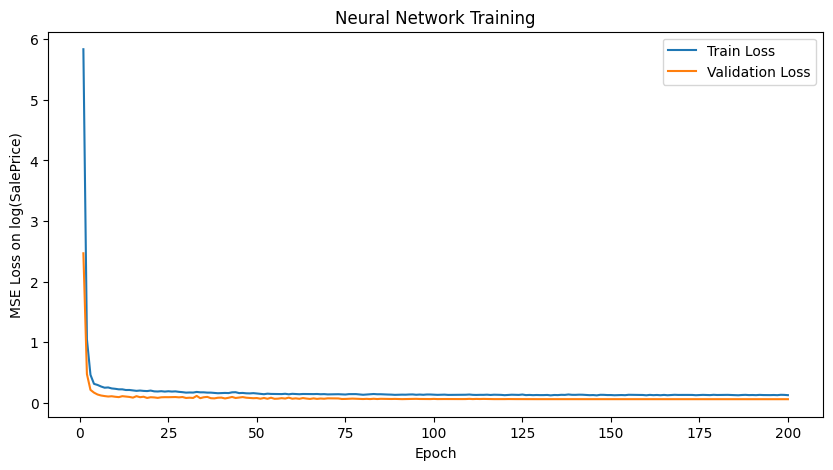

In [326]:
import copy
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print(f'Using device: {device}')


# Hyperparameters
hidden_layers = [256, 256]
lr = 0.001
dropout_rate = 0.1
batch_size = 64
n_epochs = 200

class Net(nn.Module):
    def __init__(self, input_size, hidden_layers, dropout_rate=0.2):
        super(Net, self).__init__()

        layers = []
        prev_size = input_size

        for hidden_size in hidden_layers:
            layers.append(nn.Linear(prev_size, hidden_size))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout_rate))
            prev_size = hidden_size

        layers.append(nn.Linear(prev_size, 1))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)


def fit_nn_and_predict(X_train, X_val, y_train, y_val, preprocessor, hidden_layers, dropout_rate, lr, batch_size, n_epochs, loss_history=None, fold_label=None):
    fold_preprocessor = clone(preprocessor)
    X_train_nn = fold_preprocessor.fit_transform(X_train)
    X_val_nn = fold_preprocessor.transform(X_val)

    if hasattr(X_train_nn, 'toarray'):
        X_train_nn = X_train_nn.toarray()
    if hasattr(X_val_nn, 'toarray'):
        X_val_nn = X_val_nn.toarray()

    y_train_nn = to_log_saleprice(y_train)
    y_val_nn = to_log_saleprice(y_val)

    X_train_tensor = torch.tensor(X_train_nn, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train_nn.reshape(-1, 1), dtype=torch.float32)
    X_val_tensor = torch.tensor(X_val_nn, dtype=torch.float32).to(device)
    y_val_tensor = torch.tensor(y_val_nn.reshape(-1, 1), dtype=torch.float32).to(device)

    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    model = Net(
        input_size=X_train_tensor.shape[1],
        hidden_layers=hidden_layers,
        dropout_rate=dropout_rate
    ).to(device)

    #criterion = nn.MSELoss()
    criterion = nn.SmoothL1Loss()

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='min',
        patience=10,
        factor=0.5
    )

    best_val_loss = float('inf')
    best_model_state = None

    for epoch in range(n_epochs):
        model.train()
        running_loss = 0.0

        for x_batch, y_batch in train_loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()
            outputs = model(x_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        epoch_loss = running_loss / len(train_loader)

        model.eval()
        with torch.no_grad():
            val_outputs = model(X_val_tensor)
            val_loss = criterion(val_outputs, y_val_tensor).item()

        scheduler.step(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = copy.deepcopy(model.state_dict())

        if loss_history is not None:
            loss_history.append({
                'fold': fold_label,
                'epoch': epoch + 1,
                'train_loss': epoch_loss,
                'val_loss': val_loss,
            })

        if (epoch + 1) % 10 == 0:
            print(
                f'Fold {fold_label} - Epoch [{epoch+1}/{n_epochs}], '
                f'Train Loss: {epoch_loss:.4f}, '
                f'Val Loss: {val_loss:.4f}'
            )

    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    model.eval()
    with torch.no_grad():
        y_pred_log = model(X_val_tensor).cpu().numpy().flatten()

    return y_pred_log

nn_fold_results = []
loss_history = []
# Choose dataset for NN
nn_data = dataset_versions['nn_numeric'] 
#nn_data = dataset_versions['nn_numeric_reduced']

X_nn = nn_data['X']
y_nn = nn_data['y']
nn_preprocessor = build_numeric_preprocessor(nn_data)

#X_train_outer, X_val_outer, y_train_outer, y_val_outer = split_train_validation(feature_frame, y_sale)
X_train_outer, X_val_outer, y_train_outer, y_val_outer = split_train_validation(X_nn, y_nn)

for fold, X_train, X_val, y_sale_train, y_sale_val in iter_stratified_folds(X_train_outer, y_train_outer):
    torch.manual_seed(RANDOM_STATE + fold)
    y_pred_log = fit_nn_and_predict(
        X_train,
        X_val,
        y_sale_train,
        y_sale_val,
        nn_preprocessor,
        hidden_layers,
        dropout_rate,
        lr,
        batch_size,
        n_epochs,
        loss_history=loss_history,
        fold_label=fold,
    )
    nn_fold_results.append(log_saleprice_metrics(y_sale_val, y_pred_log))

torch.manual_seed(RANDOM_STATE)
y_pred_log = fit_nn_and_predict(
    X_train_outer,
    X_val_outer,
    y_train_outer,
    y_val_outer,
    nn_preprocessor,
    hidden_layers,
    dropout_rate,
    lr,
    batch_size,
    n_epochs,
)

nn_results = summarize_model_results([
    {
        'model': 'NeuralNetwork',
        **aggregate_cv_metrics(nn_fold_results),
        **prefix_metrics(log_saleprice_metrics(y_val_outer, y_pred_log), 'val'),
    }
], sort_columns=('val_rmse_log_saleprice',))

loss_history_df = pd.DataFrame(loss_history)
mean_loss_history = loss_history_df.groupby('epoch')[['train_loss', 'val_loss']].mean()

plt.figure(figsize=(10, 5))
plt.plot(mean_loss_history.index, mean_loss_history['train_loss'], label='Train Loss')
plt.plot(mean_loss_history.index, mean_loss_history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss on log(SalePrice)')
plt.title('Neural Network Training')
plt.legend()
plt.show()

In [327]:
nn_results

,model,cv_rmse_log_saleprice,cv_rmse_saleprice,cv_mae_saleprice,cv_r2_saleprice,cv_avg_pct_error,cv_max_abs_error_saleprice,cv_min_abs_error_saleprice,val_rmse_log_saleprice,val_rmse_saleprice,val_mae_saleprice,val_r2_saleprice,val_avg_pct_error,val_max_abs_error_saleprice,val_min_abs_error_saleprice
0,NeuralNetwork,0.381142,2.030462e+06,201456.108919,-3252.747593,80.539809,1.442286e+08,4.540696,0.32027,93603.895361,43223.42267,-0.366695,24.816355,1.105804e+06,65.059517


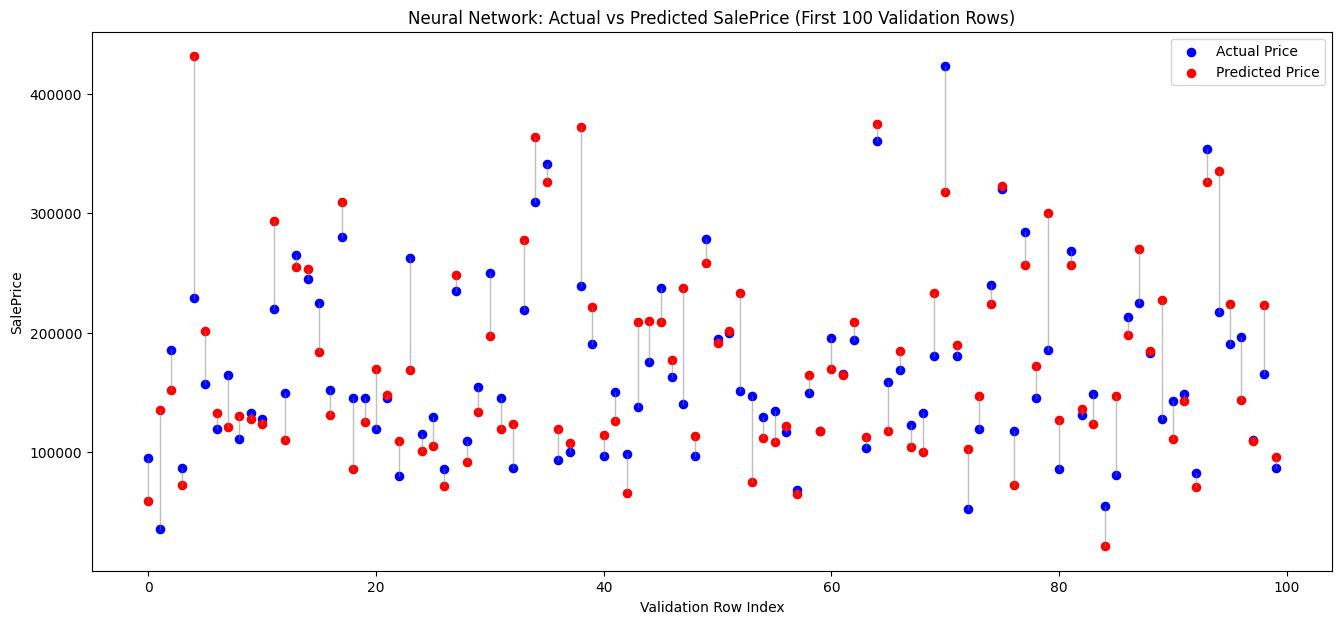

In [328]:
nn_actual_price = y_val_outer.to_numpy()
nn_pred_price = np.exp(y_pred_log)

plot_df = pd.DataFrame({
    'ActualPrice': nn_actual_price,
    'PredictedPrice': nn_pred_price
}).iloc[:100].reset_index(drop=True)

plt.figure(figsize=(16, 7))

x = np.arange(len(plot_df))

for i in range(len(plot_df)):
    plt.plot(
        [x[i], x[i]],
        [plot_df.loc[i, 'ActualPrice'], plot_df.loc[i, 'PredictedPrice']],
        color='gray',
        alpha=0.5,
        linewidth=1
    )

plt.scatter(x, plot_df['ActualPrice'], label='Actual Price', color='blue', s=35)
plt.scatter(x, plot_df['PredictedPrice'], label='Predicted Price', color='red', s=35)

plt.title('Neural Network: Actual vs Predicted SalePrice (First 100 Validation Rows)')
plt.xlabel('Validation Row Index')
plt.ylabel('SalePrice')
plt.legend()
plt.show()


Submission function

In [ ]:
from pathlib import Path
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from catboost import CatBoostRegressor
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader


def build_impute_only_numeric_preprocessor(dataset_data):
    return ColumnTransformer(
        transformers=[
            (
                'imputed_num',
                Pipeline([
                    ('imputer', SimpleImputer(strategy='median')),
                ]),
                dataset_data.get('scale_columns', []),
            ),
            (
                'ordinal_passthrough',
                Pipeline([
                    ('imputer', SimpleImputer(strategy='most_frequent')),
                ]),
                dataset_data.get('ordinal_columns', []),
            ),
            (
                'non_scaled_passthrough',
                Pipeline([
                    ('imputer', SimpleImputer(strategy='most_frequent')),
                ]),
                dataset_data.get('non_scaled_columns', []),
            ),
        ],
        remainder='drop',
    )


def build_test_dataset(dataset_key, prepared_test_df=None):
    prepared_test_df = test_prepared if prepared_test_df is None else prepared_test_df

    if dataset_key not in dataset_versions:
        raise KeyError(f'Unknown dataset_key: {dataset_key}')

    train_dataset = dataset_versions[dataset_key]

    if train_dataset.get('encoding') == 'onehot':
        X_test = prepared_test_df.drop(columns=[TARGET, *EXCLUDED_FEATURE_COLUMNS], errors='ignore').copy()
        X_test = prepare_onehot_features(X_test)
        X_test = X_test.reindex(columns=train_dataset['X'].columns, fill_value=0.0)
    elif train_dataset.get('cat_features'):
        X_test = prepared_test_df.drop(columns=[TARGET, *EXCLUDED_FEATURE_COLUMNS], errors='ignore').copy()
        for column in train_dataset.get('cat_features', []):
            if column in X_test.columns:
                X_test[column] = X_test[column].fillna('Missing').astype(str)
        X_test = X_test.reindex(columns=train_dataset['X'].columns)
    else:
        X_test = prepared_test_df.select_dtypes(include='number').drop(columns=[TARGET, *EXCLUDED_FEATURE_COLUMNS], errors='ignore').copy()
        X_test = X_test.reindex(columns=train_dataset['X'].columns)

    return {
        'X': X_test,
        'cat_features': train_dataset.get('cat_features', []),
        'target': train_dataset.get('target'),
    }


def get_training_target(dataset_data, target_strategy):
    if target_strategy == 'log_saleprice':
        return to_log_saleprice(dataset_data['y'])

    if target_strategy == 'log_price_per_sqft':
        if 'GrLivArea' not in dataset_data['X'].columns:
            raise KeyError('GrLivArea is required for log_price_per_sqft target strategy.')

        gr_liv_area = dataset_data['X']['GrLivArea'].to_numpy(dtype=float)
        if np.any(gr_liv_area <= 0):
            raise ValueError('GrLivArea must be strictly positive for log_price_per_sqft target strategy.')

        return np.log(np.asarray(dataset_data['y'], dtype=float) / gr_liv_area)

    raise ValueError(f'Unsupported target_strategy: {target_strategy}')


def convert_predictions_to_saleprice(y_pred_target, X_features, target_strategy):
    y_pred_target = np.asarray(y_pred_target, dtype=float)

    if target_strategy == 'log_saleprice':
        return from_log_saleprice(y_pred_target)

    if target_strategy == 'log_price_per_sqft':
        if 'GrLivArea' not in X_features.columns:
            raise KeyError('GrLivArea is required to convert log_price_per_sqft predictions back to SalePrice.')

        gr_liv_area = X_features['GrLivArea'].to_numpy(dtype=float)
        if np.any(gr_liv_area <= 0):
            raise ValueError('GrLivArea must be strictly positive to convert log_price_per_sqft predictions back to SalePrice.')

        return np.exp(y_pred_target) * gr_liv_area

    raise ValueError(f'Unsupported target_strategy: {target_strategy}')


def sanitize_output_name(name):
    return ''.join(character if character.isalnum() or character in {'_', '-'} else '_' for character in name.lower())


def build_submission_preprocessor(dataset_data, preprocessor_kind):
    if preprocessor_kind == 'scaled':
        return build_numeric_preprocessor(dataset_data)
    if preprocessor_kind == 'impute_only':
        return build_impute_only_numeric_preprocessor(dataset_data)
    if preprocessor_kind is None:
        return None

    raise ValueError(f'Unsupported preprocessor_kind: {preprocessor_kind}')


class SubmissionNet(nn.Module):
    def __init__(self, input_size, hidden_layers, dropout_rate=0.2):
        super().__init__()

        layers = []
        prev_size = input_size

        for hidden_size in hidden_layers:
            layers.append(nn.Linear(prev_size, hidden_size))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout_rate))
            prev_size = hidden_size

        layers.append(nn.Linear(prev_size, 1))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)


def fit_nn_submission_predict(train_dataset, test_dataset, model_config):
    submission_device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
    X_train_full = train_dataset['X']
    y_train_full = train_dataset['y']
    X_train_inner, X_val_inner, y_train_inner, y_val_inner = split_train_validation(
        X_train_full,
        y_train_full,
        validation_size=model_config.get('validation_size', 0.15),
    )

    nn_preprocessor = build_numeric_preprocessor(train_dataset)
    fitted_preprocessor = clone(nn_preprocessor)

    X_train_nn = fitted_preprocessor.fit_transform(X_train_inner)
    X_val_nn = fitted_preprocessor.transform(X_val_inner)
    X_test_nn = fitted_preprocessor.transform(test_dataset['X'])

    if hasattr(X_train_nn, 'toarray'):
        X_train_nn = X_train_nn.toarray()
    if hasattr(X_val_nn, 'toarray'):
        X_val_nn = X_val_nn.toarray()
    if hasattr(X_test_nn, 'toarray'):
        X_test_nn = X_test_nn.toarray()

    y_train_target = get_training_target({'X': X_train_inner, 'y': y_train_inner}, model_config['target_strategy'])
    y_val_target = get_training_target({'X': X_val_inner, 'y': y_val_inner}, model_config['target_strategy'])

    X_train_tensor = torch.tensor(X_train_nn, dtype=torch.float32)
    y_train_tensor = torch.tensor(np.asarray(y_train_target).reshape(-1, 1), dtype=torch.float32)
    X_val_tensor = torch.tensor(X_val_nn, dtype=torch.float32).to(submission_device)
    y_val_tensor = torch.tensor(np.asarray(y_val_target).reshape(-1, 1), dtype=torch.float32).to(submission_device)
    X_test_tensor = torch.tensor(X_test_nn, dtype=torch.float32).to(submission_device)

    train_dataset_torch = TensorDataset(X_train_tensor, y_train_tensor)
    train_loader = DataLoader(
        train_dataset_torch,
        batch_size=model_config.get('batch_size', 64),
        shuffle=True,
    )

    torch.manual_seed(model_config.get('random_state', RANDOM_STATE))
    model = SubmissionNet(
        input_size=X_train_tensor.shape[1],
        hidden_layers=model_config.get('hidden_layers', [256, 256]),
        dropout_rate=model_config.get('dropout_rate', 0.1),
    ).to(submission_device)

    criterion = model_config.get('criterion', nn.SmoothL1Loss())
    optimizer = torch.optim.Adam(model.parameters(), lr=model_config.get('lr', 0.001))
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='min',
        patience=model_config.get('scheduler_patience', 10),
        factor=model_config.get('scheduler_factor', 0.5),
    )

    best_val_loss = float('inf')
    best_model_state = None

    for epoch in range(model_config.get('n_epochs', 200)):
        model.train()

        for x_batch, y_batch in train_loader:
            x_batch = x_batch.to(submission_device)
            y_batch = y_batch.to(submission_device)

            optimizer.zero_grad()
            outputs = model(x_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()

        model.eval()
        with torch.no_grad():
            val_outputs = model(X_val_tensor)
            val_loss = criterion(val_outputs, y_val_tensor).item()

        scheduler.step(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = copy.deepcopy(model.state_dict())

    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    model.eval()
    with torch.no_grad():
        y_pred_target = model(X_test_tensor).cpu().numpy().flatten()

    return convert_predictions_to_saleprice(
        y_pred_target,
        test_dataset['X'],
        model_config['target_strategy'],
    )


def fit_and_predict_submission(model_name, dataset_key, train_dataset, test_dataset):
    if model_name not in SUBMISSION_MODEL_REGISTRY:
        raise KeyError(f'Unknown model_name: {model_name}')

    model_config = SUBMISSION_MODEL_REGISTRY[model_name]

    if model_config['family'] == 'nn':
        return fit_nn_submission_predict(train_dataset, test_dataset, model_config)

    train_target = get_training_target(train_dataset, model_config['target_strategy'])

    if model_config['family'] == 'catboost':
        estimator = model_config['factory']()
        estimator.fit(
            train_dataset['X'],
            train_target,
            cat_features=train_dataset.get('cat_features', []),
        )
        y_pred_target = estimator.predict(test_dataset['X'])
        return convert_predictions_to_saleprice(
            y_pred_target,
            test_dataset['X'],
            model_config['target_strategy'],
        )

    preprocessor = build_submission_preprocessor(train_dataset, model_config['preprocessor_kind'])
    estimator = model_config['factory']()
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', estimator),
    ])
    pipeline.fit(train_dataset['X'], train_target)
    y_pred_target = pipeline.predict(test_dataset['X'])

    return convert_predictions_to_saleprice(
        y_pred_target,
        test_dataset['X'],
        model_config['target_strategy'],
    )


SUBMISSION_MODEL_REGISTRY = {
    # Generic baseline entries kept for reference.
    'linear_regression': {
        'family': 'sklearn',
        'factory': lambda: LinearRegression(),
        'preprocessor_kind': 'scaled',
        'target_strategy': 'log_saleprice',
    },
    'linear_regression_ppsqft': {
        'family': 'sklearn',
        'factory': lambda: LinearRegression(),
        'preprocessor_kind': 'scaled',
        'target_strategy': 'log_price_per_sqft',
    },
    'lasso': {
        'family': 'sklearn',
        'factory': lambda: Lasso(alpha=0.001, max_iter=12000),
        'preprocessor_kind': 'scaled',
        'target_strategy': 'log_saleprice',
    },
    'ridge': {
        'family': 'sklearn',
        'factory': lambda: Ridge(alpha=1.0),
        'preprocessor_kind': 'scaled',
        'target_strategy': 'log_price_per_sqft',
        'preferred_dataset_key': 'linear_price_comparison',
    },
    'linear': {
        'family': 'sklearn',
        'factory': lambda: Ridge(alpha=1.0),
        'preprocessor_kind': 'scaled',
        'target_strategy': 'log_price_per_sqft',
        'preferred_dataset_key': 'linear_price_comparison',
    },
    'elasticnet': {
        'family': 'sklearn',
        'factory': lambda: ElasticNet(alpha=2.477076, l1_ratio=0.7, max_iter=20000),
        'preprocessor_kind': 'scaled',
        'target_strategy': 'log_saleprice',
    },
    'knn': {
        'family': 'sklearn',
        'factory': lambda: KNeighborsRegressor(n_neighbors=11, weights='distance', p=1, n_jobs=-1),
        'preprocessor_kind': 'scaled',
        'target_strategy': 'log_price_per_sqft',
        'preferred_dataset_key': 'linear_price_comparison',
    },
    'decision_tree': {
        'family': 'sklearn',
        'factory': lambda: DecisionTreeRegressor(
            max_depth=10,
            min_samples_split=10,
            min_samples_leaf=2,
            criterion='poisson',
            random_state=RANDOM_STATE,
        ),
        'preprocessor_kind': 'impute_only',
        'target_strategy': 'log_saleprice',
        'preferred_dataset_key': 'processed_full_numeric',
    },
    'random_forest': {
        'family': 'sklearn',
        'factory': lambda: RandomForestRegressor(
            n_estimators=300,
            criterion='squared_error',
            max_depth=20,
            min_samples_split=2,
            min_samples_leaf=1,
            max_features=1.0,
            bootstrap=True,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ),
        'preprocessor_kind': 'impute_only',
        'target_strategy': 'log_saleprice',
        'preferred_dataset_key': 'processed_full_numeric',
    },
    'catboost': {
        'family': 'catboost',
        'factory': lambda: CatBoostRegressor(
            iterations=600,
            learning_rate=0.06,
            depth=4,
            l2_leaf_reg=3,
            loss_function='RMSE',
            random_seed=RANDOM_STATE,
            verbose=False,
        ),
        'target_strategy': 'log_saleprice',
        'preferred_dataset_key': 'catboost_processed_mixed',
    },
    'neural_network': {
        'family': 'nn',
        'target_strategy': 'log_saleprice',
        'hidden_layers': globals().get('hidden_layers', [256, 256]),
        'lr': globals().get('lr', 0.001),
        'dropout_rate': globals().get('dropout_rate', 0.1),
        'batch_size': globals().get('batch_size', 64),
        'n_epochs': globals().get('n_epochs', 200),
        'validation_size': 0.15,
        'random_state': RANDOM_STATE,
        'criterion': nn.SmoothL1Loss(),
        'preferred_dataset_key': 'nn_numeric',
    },
}


def make_submission(model_name, dataset_key, filename=None, output_dir=OUTPUT_DIR):
    if dataset_key not in dataset_versions:
        raise KeyError(f'Unknown dataset_key: {dataset_key}')

    train_dataset = dataset_versions[dataset_key]
    test_dataset = build_test_dataset(dataset_key)
    saleprice_predictions = fit_and_predict_submission(model_name, dataset_key, train_dataset, test_dataset)

    submission_df = pd.DataFrame({
        'Id': raw_test['Id'],
        'SalePrice': saleprice_predictions,
    })

    if filename is None:
        filename = f"output_{sanitize_output_name(model_name)}.csv"

    output_path = Path(output_dir) / filename
    submission_df.to_csv(output_path, index=False)
    print(f'Saved submission to {output_path}')

    return submission_df, output_path


# Generate submission files
make_submission('linear', 'linear_price_comparison', filename='output_linear.csv')
#0.13970
make_submission('knn', 'linear_price_comparison', filename='output_knn.csv')
#0.16609
make_submission('decision_tree', 'processed_full_numeric', filename='output_decision_tree.csv')
#0.18643
make_submission('random_forest', 'processed_full_numeric', filename='output_random_forest.csv')
#0.14348
make_submission('catboost', 'catboost_processed_mixed', filename='output_catboost.csv')
#0.11991 - best
make_submission('neural_network', 'nn_numeric_reduced', filename='output_neural_network_reduced.csv')
#0.19464
make_submission('decision_tree', 'processed_full_onehot', filename='output_decision_tree_onehot.csv')
#0.19189
make_submission('random_forest', 'processed_full_onehot', filename='output_random_forest_onehot.csv')
#0.14330


Saved submission to /Users/Admin/Documents/VSCode/Housing-Prices/output_linear.csv
Saved submission to /Users/Admin/Documents/VSCode/Housing-Prices/output_knn.csv
Saved submission to /Users/Admin/Documents/VSCode/Housing-Prices/output_decision_tree.csv
Saved submission to /Users/Admin/Documents/VSCode/Housing-Prices/output_random_forest.csv
Saved submission to /Users/Admin/Documents/VSCode/Housing-Prices/output_catboost.csv
Saved submission to /Users/Admin/Documents/VSCode/Housing-Prices/output_neural_network_reduced.csv
Saved submission to /Users/Admin/Documents/VSCode/Housing-Prices/output_decision_tree_onehot.csv
Saved submission to /Users/Admin/Documents/VSCode/Housing-Prices/output_random_forest_onehot.csv


(        Id      SalePrice
 0     1461  124539.100231
 1     1462  152385.047252
 2     1463  182922.305158
 3     1464  180319.264616
 4     1465  195051.060336
 ...    ...            ...
 1454  2915   83611.355928
 1455  2916   83411.531838
 1456  2917  154628.434504
 1457  2918  113940.959526
 1458  2919  232653.450613
 
 [1459 rows x 2 columns],
 PosixPath('/Users/Admin/Documents/VSCode/Housing-Prices/output_random_forest_onehot.csv'))